***---------------------------------------------------------Global Expansion of Japanese IP-------------------------------------------------------*** 

In [2]:
#regular libraries 
import requests
import pandas as pd 
import time 
from bs4 import BeautifulSoup
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import numpy as np
import os 


In [2]:
#Machine Learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import SMOTE

In [3]:
#Streamlist libraries
import streamlit as st
import joblib as joblib

****---------------------------------------------------------------[About Jikan API]------------------------------------------------------------****

Web Scraping of https://myanimelist.net/, which is the world’s largest online database and social community dedicated to Japanese animation (Anime) and comics (Manga). 

***Score***
- Bayesian weighted  
- $S$: The average score given by users for that specific anime.
- $v$: The number of users who have "voted" for the anime.
- $m$: The minimum number of votes required to get a public score (currently 50).
- $C$: The average score across the entire MAL database.

***Reach Members***

This measures how many people discovered the series. 
It is usually calculated based on the number of unique users who added the manga/anime to their list (Plan to Watch, Reading, or Completed).

***Loyalty Favourite***

This measures how many people stuck with it. It is the percentage of users who started the series and actually finished it (or are currently up to date) versus those who dropped it early. High loyalty suggests the story keeps viewer engaged.

***Popularity Rank***



***Demographics***
- Average age 24-25 
- United States: Consistently the #1 source of traffic (often 20% or more).
- Indonesia: A massive and very active community.
- Germany: One of the strongest European user bases.
- United Kingdom: High engagement in discussions and forums.
- Canada / Brazil: These two often rotate for the fifth spot depending on seasonal trends.


****----------------------------------------------------------[Manga Datafram from Jikan API]----------------------------------------------------****

I am utilising the Jikan API to extract Manga-specific metadata first. 

From Initial Manga IP research it can be concluded that Key Features for successful Manga based IP parameters include :
-  Serialization (Jump/Jump+ by the Japan's biggest Manga publisher, Shueisha) 
-  Score
-  Streaming
-  Award

In [4]:
#[Manga DataFrame]
#Reading the JikanAPI to see if the call is successful 
jikan_url = "http://discord.jikan.moe"
response = requests.get (jikan_url)
response.status_code

200

In [5]:
#[Manga DataFrame]
#Testing the API call with 3 Manga originated Global Intellectual Property Hits; 'One Piece', 'Kimetsu no Yaiba (Demon Slayers)', 'Dandadan'
def get_manga_info(manga_id):
    url = f"https://api.jikan.moe/v4/manga/{manga_id}/full"
    
    try:
        response = requests.get(url)
        
        if response.status_code != 200:
            print(f"Server Error for ID {manga_id}: {response.status_code}")
            return None
            
        if not response.text.strip():
            print(f"Empty envelope for ID {manga_id}. The server sent nothing.")
            return None
            
        return response.json()['data']
        
    except Exception as e:
        print(f"Connection error for ID {manga_id}: {e}")
        return None

ids = [13, 96792, 135496] # One Piece, Demon Slayer, Dandadan
manga_results = []

for m_id in ids:
    data = get_manga_info(m_id)
    if data:
        manga_results.append(data)
        print(f"Successfully pulled: {data['title']}")
    
    # wait 2 seconds before running it again 
    time.sleep(2)

Successfully pulled: One Piece
Successfully pulled: Kimetsu no Yaiba
Successfully pulled: Dandadan


In [6]:
#[Manga DataFrame]
#Checking the table conversion with the newest Manga based IP hit, 'Dandadan'
m_id = 135496
url = f"https://api.jikan.moe/v4/manga/{m_id}/full"

response = requests.get(url)

manga_data = [] 

# 3. THE SAFETY CHECK
if response.status_code == 200:
    try:
        # Try to get the JSON
        json_payload = response.json()
        item = json_payload['data']
        
        # specifying the columns
        row = {
            'Manga_ID': item.get('mal_id'),
            'Title' : item.get('title'), 
            'Score' : item.get('score'),
            'Reach_Members': item.get('members'),
            'Loyalty_Favourites':item.get('favorites'),
            'Synopsis' : item.get('synopsis'),
            'Background' : item.get('background'), 
            'Comic Mag' : item.get ('serializations'),
            'Main_Genre' : item['genres'][0]['name'] if item['genres'] else 'N/A'
        }
        
        # appending the API responses into manga_data tuple, checking if it worked 
        manga_data.append(row) 
        print(f"Successfully grabbed: {item.get('title')}")
        
    except Exception as e:
        print(f"JSON Error: {e}")
else:
    print(f"API Error! Status Code: {response.status_code}")
    print("Wait 1 minute and try again. You might be rate-limited.")

manga_df = pd.DataFrame(manga_data) #converting it into dataframe 
manga_df

Successfully grabbed: Dandadan


,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Main_Genre
0,135496,Dandadan,8.44,207515,10871,"After being aggressively rejected, Momo Ayase ...",Dandadan ranked fourth in the 2022 Kono Manga ...,"[{'mal_id': 1209, 'type': 'manga', 'name': 'Sh...",Action


In [3]:
#[Manga DataFrame]
#Collecting 1000 Manga Titles data that includes useful features of its IP success such as serialisation, from Jikan API  
manga_data = []
target_count = 1000
page = 1

print("Starting Manga Data Collection...")

while len(manga_data) < target_count:
    url = f"https://api.jikan.moe/v4/top/manga?page={page}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json().get('data', [])
        
        for item in data:
            if len(manga_data) >= target_count:
                break
                
            row = {
                'Manga_ID': item.get('mal_id'),
                'Title' : item.get('title'), 
                'Score' : item.get('score'),
                'Reach_Members': item.get('members'),
                'Loyalty_Favourites': item.get('favorites'),
                'Synopsis' : item.get('synopsis'),
                'Background' : item.get('background'), 
                'Comic Mag' : item['serializations'][0]['name'] if item.get('serializations') else 'N/A', #'Main_Genre' : item['genres'][0]['name'] if item.get('genres') else 'N/A'
                'Genres' : ", ".join([g['name'] for g in item.get('genres', [])]) if item.get('genres') else 'N/A'
            }
            manga_data.append(row)
        
        print(f"✅ Page {page} done. Total Collected: {len(manga_data)}")
        page += 1
        time.sleep(1) #mitigation for 429 errors
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting 30 seconds...")
        time.sleep(30)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        break

# Turn into DataFrame
manga_df = pd.DataFrame(manga_data)

# Saving this on csv 
manga_df.to_csv('top_manga_dataset.csv', index=False)
print("Data saved to 'top_manga_dataset.csv'!")

Starting Manga Data Collection...
✅ Page 1 done. Total Collected: 25
✅ Page 2 done. Total Collected: 50
✅ Page 3 done. Total Collected: 75
✅ Page 4 done. Total Collected: 100
✅ Page 5 done. Total Collected: 125
✅ Page 6 done. Total Collected: 150
✅ Page 7 done. Total Collected: 175
✅ Page 8 done. Total Collected: 200
✅ Page 9 done. Total Collected: 225
✅ Page 10 done. Total Collected: 250
✅ Page 11 done. Total Collected: 275
✅ Page 12 done. Total Collected: 300
✅ Page 13 done. Total Collected: 325
✅ Page 14 done. Total Collected: 350
✅ Page 15 done. Total Collected: 375
✅ Page 16 done. Total Collected: 400
✅ Page 17 done. Total Collected: 425
✅ Page 18 done. Total Collected: 450
✅ Page 19 done. Total Collected: 475
✅ Page 20 done. Total Collected: 500
✅ Page 21 done. Total Collected: 525
✅ Page 22 done. Total Collected: 550
✅ Page 23 done. Total Collected: 575
✅ Page 24 done. Total Collected: 600
✅ Page 25 done. Total Collected: 625
✅ Page 26 done. Total Collected: 650
✅ Page 27 done. 

In [ ]:
#[Manga DataFrame]
#Further refining and filtering the table with success factors such as language translations, award, streaming

#Column that list translated languages 
target_languages = ['English', 'Korean', 'Malay', 'Indonesian', 'Chinese', 'Thai', 'Vietnamese', 'German', 'French', 'Italian', 'Spanish', 'Portuguese', 'Swedish', 'Danish', 'Norwegian', 'Finnish', 'Polish', 'Turkish', 'Russian']
def check_language(text):
    if not text : 
        return "None"
    found = [lang for lang in target_languages if lang in text]
    return ", ".join(found) if found else "None"
manga_df['Languages'] = manga_df ['Background'].apply(check_language) 
manga_df['Language_count'] = manga_df['Languages'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))

#Column that check if any award was given  
award_keywords = ['award', 'Award', 'prize', 'winner', 'finalist']
def check_award(text):
    if not text : 
        return "None"
    found = [word for word in award_keywords if word in text]
    return ", ".join(found) if found else "None"
manga_df['Award_Types'] = manga_df ['Background'].apply(check_award) 
manga_df['Award_count'] = manga_df['Award_Types'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))

#Column that check if it's available in streaming services 
streaming = ['amazon', 'netflix', 'crunchroll', 'viz', 'manga plus']
def check_streaming(text):
    if not text : 
        return "None"
    found = [s for s in streaming if s in text.lower()]
    return ", ".join(found) if found else "None"
manga_df['Streaming'] = manga_df ['Background'].apply(check_streaming) 
manga_df['Streaming_count'] = manga_df['Streaming'].apply(lambda x: 0 if x == 'None' else len (x.split (',')))
manga_df.head(3)

****-------------------------------------------------[Manga DataFrame Exploratory Data Analysis]-------------------------------------------------****

In [ ]:
#[Manga DataFrame]
#Sorting the table by streaming count, as this will be many if the title has profitable success
#loyalty favourites also will tell the impact of the global IP success 
#Score is rated by 
top_manga = manga_df.sort_values(by=['Streaming_count', 'Loyalty_Favourites','Score'], ascending=False)

# View the top 5 to analyse the pattern 
top_manga.head(5)

In [ ]:
#[Manga Dataframe] 
#Evaluating which language is most translated / popularity index 
#Filtering English and None out 
all_langs = manga_df['Languages'].str.split(',').explode().str.strip()
excluded = ['None']
langs_filtered = all_langs[~all_langs.isin(excluded)].dropna()

#Top 10
language_counts = langs_filtered.value_counts().head(10)

#Plotting 
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")


sns.barplot(x=language_counts.values, y=language_counts.index, palette="magma")

plt.title('Top 5 Translated Languages for Manga', fontsize=16, pad=20)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Language', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
language_counts

In [ ]:
#[Manga Datafram]
#Checking the data types just in case, no many null values 
manga_df.info()

In [ ]:
#[Manga Dataframe] 
#Getting a quick feel of the Manga DataFrame so I can do necessary cleaning before putting everything together for ML 
manga_df.describe()
#SCORE: 7.9~9.4, 75% is 8.3, so for the score to be 'high', it should be above 8.3 
#REACH MEMBERS : 48.3K is mean for Reach Members, 781K for max, but I know that Reach Members is not a good contributor to IP hit prediction 
#LOYALTY FAVOURITES :  Max is 136K, mean is 0.28K, quite a range 

In [ ]:
#[Manga Dataframe]
#Identifying 'the outstanding' quality range (Top 20-25)
#SCORE : 9 to 9.4, REACH_MEMBERS : 450K+, Loyalty Favourites : 60K + 

cols_to_plot = ['Score', 'Reach_Members']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(cols_to_plot):
    sns.boxplot(y=manga_df[col], ax=axes[i], color='purple')
    axes[i].set_title(f'Range of {col}')

In [ ]:
#[Manga Dataframe]
sns.boxplot(x = manga_df['Loyalty_Favourites'], color="purple");

****----------------------------------------------------------------[ANIME DATAFRAME]------------------------------------------------------------****

From the same Jikan API, create a table that contains all the data that includes non-Manga

***Originated_From***
- Visual novel
- Light novel
- Novel
- Original (Animation studio created the IP)
- Web manga
- 4-koma (4 frames) manga
- Web novel
- Music
- Game
- Other
- Book
- Mixed media
- Picture book

In [ ]:
#[Anime DataFrame]
#Collecting 1000 Anime Titles data that includes useful features of its IP success from Jikan API  

anime_data = []
target_count = 1000
page = 1

print("Starting Anime Data Collection...")

while len(anime_data) < target_count:
    url = f"https://api.jikan.moe/v4/top/anime?page={page}"
    response = requests.get(url)

    if response.status_code == 200:
        data = response.json().get('data', [])
        
        for item in data:
            if len(anime_data) >= target_count:
                break
            
            # The dictionary must be indented inside the 'for item in data' loop
            row = {
                'Anime_ID': item.get('mal_id'),
                'Title': item.get('title'),
        
                # STORY DNA & ORIGIN
                'Originated_From': item.get('source'), 
                'Story_DNA': item.get('synopsis'),      
        
                # MARKET PERFORMANCE
                'Popularity_Rank': item.get('popularity'), 
                'Score': item.get('score'),
                'Reach_Members': item.get('members'),      
                'Loyalty_Favourites': item.get('favorites'), 
        
                # CATEGORIZATION
                'Main_Genre': ", ".join([g['name'] for g in item.get('genres', [])]) if item.get('genres') else 'N/A',
        
                # PRODUCTION DATA
                'Studios': ", ".join([s['name'] for s in item.get('studios', [])]) if item.get('studios') else 'N/A',
                'Producers': item.get('producers'), 
                'Licensors': item.get('licensors'),
        
                # LOGISTICS
                'Episodes': item.get('episodes'),  
                'Airing_Year': item.get('year'),
                'Rating': item.get('rating')            
            }
            anime_data.append(row)
        
        print(f"✅ Page {page} done. Total Collected: {len(anime_data)}")
        page += 1
        time.sleep(1) # mitigation for 429 errors
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting 30 seconds...")
        time.sleep(30)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        break

anime_df = pd.DataFrame(anime_data)
# Saving this on csv 
anime_df.to_csv('top_anime_dataset.csv', index=False)
print("Data saved to 'top_anime_dataset.csv'!")

****--------------------------------------------[Anime DataFrame Exploratory Data Analysis] ---------------------------------------------------****

In [8]:
#[Anime DataFrame]
#reading the data from csv 
anime_df = pd.read_csv('top_anime_dataset.csv')

In [9]:
#[Anime DataFrame]
#Checking how API data was converted into dataframe, checking the top 5 sorted by Loyalty_Favourites 
anime_df.sort_values(by='Loyalty_Favourites', ascending=False).head(5)

,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,Producers,Licensors,Episodes,Airing_Year,Rating
51,21,One Piece,Manga,Barely surviving in a barrel after passing thr...,17,8.73,2629040,247885,"Action, Adventure, Fantasy",Toei Animation,"[{'mal_id': 169, 'type': 'anime', 'name': 'Fuj...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",NaN,1999.0,PG-13 - Teens 13 or older
3,5114,Fullmetal Alchemist: Brotherhood,Manga,After a horrific alchemy experiment goes wrong...,3,9.10,3628507,239718,"Action, Adventure, Drama, Fantasy",Bones,"[{'mal_id': 17, 'type': 'anime', 'name': 'Anip...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",64.0,2009.0,R - 17+ (violence & profanity)
8,11061,Hunter x Hunter (2011),Manga,Hunters devote themselves to accomplishing haz...,8,9.03,3134015,226770,"Action, Adventure, Fantasy",Madhouse,"[{'mal_id': 29, 'type': 'anime', 'name': 'VAP'...","[{'mal_id': 119, 'type': 'anime', 'name': 'VIZ...",148.0,2011.0,PG-13 - Teens 13 or older
4,9253,Steins;Gate,Visual novel,Eccentric scientist Rintarou Okabe has a never...,14,9.07,2773782,200310,"Drama, Sci-Fi, Suspense",White Fox,"[{'mal_id': 61, 'type': 'anime', 'name': 'Fron...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",24.0,2011.0,PG-13 - Teens 13 or older
122,16498,Shingeki no Kyojin,Manga,"Centuries ago, mankind was slaughtered to near...",1,8.57,4294810,186235,"Action, Award Winning, Drama, Suspense",Wit Studio,"[{'mal_id': 10, 'type': 'anime', 'name': 'Prod...","[{'mal_id': 102, 'type': 'anime', 'name': 'Fun...",25.0,2013.0,R - 17+ (violence & profanity)


In [10]:
#[Anime DataFrame]
#checking data types of the anime dataframe 
anime_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Originated_From     1000 non-null   object 
 3   Story_DNA           998 non-null    object 
 4   Popularity_Rank     1000 non-null   int64  
 5   Score               1000 non-null   float64
 6   Reach_Members       1000 non-null   int64  
 7   Loyalty_Favourites  1000 non-null   int64  
 8   Main_Genre          978 non-null    object 
 9   Studios             993 non-null    object 
 10  Producers           1000 non-null   object 
 11  Licensors           1000 non-null   object 
 12  Episodes            990 non-null    float64
 13  Airing_Year         560 non-null    float64
 14  Rating              1000 non-null   object 
dtypes: float64(3), int64(4), object(8)
memory usage: 117.3+ 

In [11]:
#[Anime DataFrame]
#Data Cleaning 
#Encoding the object into numerical 
cols_to_convert = ['Studios', 'Main_Genre', 'Originated_From']
all_mappings = {}

for col in cols_to_convert:
    coded_values, unique_labels = pd.to_numeric(anime_df[col]).factorize() if col == 'Rating' else pd.factorize(anime_df[col])
    
    all_mappings[col] = {i: label for i, label in enumerate(unique_labels)}
    
    anime_df[col] = coded_values

print(anime_df[cols_to_convert].head())
 
joblib.dump(all_mappings, 'category_mappings.pkl')

   Studios  Main_Genre  Originated_From
0        0           0                0
1        0           0                0
2        1           1                0
3        2           2                0
4        3           3                1


['category_mappings.pkl']

In [12]:
for col, mapping_dict in all_mappings.items():
    print(f"\n--- Mapping for {col} ---")
for code, name in mapping_dict.items():
        print(f"{code}: {name}")


--- Mapping for Studios ---

--- Mapping for Main_Genre ---

--- Mapping for Originated_From ---
0: Manga
1: Visual novel
2: Light novel
3: Novel
4: Original
5: Web manga
6: 4-koma manga
7: Web novel
8: Game
9: Music
10: Other
11: Book
12: Mixed media
13: Picture book


In [13]:
category_mappings = joblib.load('category_mappings.pkl')

# DEBUG: This will print the keys to your terminal/command prompt
print("Keys found in pkl file:", category_mappings.keys())

Keys found in pkl file: dict_keys(['Studios', 'Main_Genre', 'Originated_From'])


In [8]:
#[Anime DataFrame]
#converting Anime_ID to integer as I found out that one of the cells included texts 
anime_df['Anime_ID'] = pd.to_numeric(anime_df['Anime_ID'], errors='coerce')
anime_df = anime_df.dropna(subset=['Anime_ID'])
anime_df['Anime_ID'] = anime_df['Anime_ID'].astype(int)

***Identifying the Long Tail Anime Originated Studio from Animation School & Google Trend Search***
    
https://www.dat.ac.jp/course/anime/anime-column/anime-school/anime-overseas/

In [9]:
#[Anime DataFrame]
#1: Selected titles that are studio originated 
long_tail_studio = ['Evangelion', 'your name is', 'Cowboy Bebop', 'Violet Evergarden', 'suzume','ghost in shell', 'spiritied away', 'totoro', 'moving castle', 'kiki']
long_tail_manga = []
# 2. Join them with the '|' (OR) symbol
pattern = '|'.join(long_tail_studio) 

# 3. Search the DataFrame (case-insensitive)
# na=False prevents errors if there are empty rows
found_anime = anime_df[anime_df['Title'].str.contains(pattern, case=False, na=False)]
print(found_anime[['Anime_ID', 'Title']])

     Anime_ID                                              Title
30      37987                            Violet Evergarden Movie
47          1                                       Cowboy Bebop
69      33352                                  Violet Evergarden
118      3786                           Shin Evangelion Movie:||
129        32  Shinseiki Evangelion Movie: Air/Magokoro wo, K...
214     39741  Violet Evergarden Gaiden: Eien to Jidou Shuki ...
227     53672                   Violet Evergarden: Recollections
244         5                    Cowboy Bebop: Tengoku no Tobira
252        30                               Shinseiki Evangelion
272     37095  Violet Evergarden: Kitto "Ai" wo Shiru Hi ga K...
317      3784                             Evangelion Movie 2: Ha
370       523                                   Tonari no Totoro
373     50594                                 Suzume no Tojimari
727      2759                             Evangelion Movie 1: Jo
767     42166            

In [10]:
#[Anime DataFrame]
#Not much correlation found 
#The Long-Tails -  'Neon Genesis Evangelion', 'Cowboy Bebop', Metric-High "Favorites" ratio, even years after release.
#The Manga Boosters -	Demon Slayer, Jujutsu Kaisen, Massive "Members" count, clear link to Shueisha/Jump.
#The "Short-Tails - High-budget seasonal shows that were forgotten - High "Score" initially, but very low "Favorites" or "Popularity" growth

long_tail_astudio = [37987, 1, 33352, 3786, 32, 39741, 53672, 5, 30, 37095, 3784, 523, 50594, 2759, 42166] 

anime_df['Long_Tail_Astudio'] = anime_df['Anime_ID'].isin(long_tail_astudio).astype(int)

correlation = anime_df.corr(numeric_only=True)['Long_Tail_Astudio'].sort_values(ascending=True)
print(correlation)
corr_data = correlation.drop('Long_Tail_Astudio').to_frame()

Airing_Year          -0.080152
Popularity_Rank      -0.055817
Anime_ID             -0.051709
Studios              -0.045160
Main_Genre           -0.032649
Episodes             -0.027289
Originated_From       0.059607
Reach_Members         0.075104
Loyalty_Favourites    0.078064
Score                 0.087860
Long_Tail_Astudio     1.000000
Rating                     NaN
Name: Long_Tail_Astudio, dtype: float64


In [36]:
#[Anime DataFrame]
# Create a Studio Reputation Score based on historical performance
studio_stats = anime_df.groupby('Studios')['Score'].agg(['mean', 'count']).reset_index()
# Filter for studios with a significant body of work
reputable_studios = studio_stats[studio_stats['count'] > 5]

# Map the mean score back to the main dataframe
anime_df['Studio_Reputation'] = anime_df['Studios'].map(reputable_studios.set_index('Studios')['mean'])

#Extracting  Anime originated only  
original_winners = anime_df[anime_df['Originated_From'] == 4]

# Sort them by your Reputation metric to see the "Sakuga" leaders
top_original_studios = original_winners.sort_values(by='Studio_Reputation', ascending=False).head(3)
print(top_original_studios[['Studios', 'Studio_Reputation', 'Main_Genre', 'Score']])

     Studios  Studio_Reputation  Main_Genre  Score
811        5           8.505000          -1   7.94
164       37           8.396250          16   8.50
911        1           8.388261          32   7.90


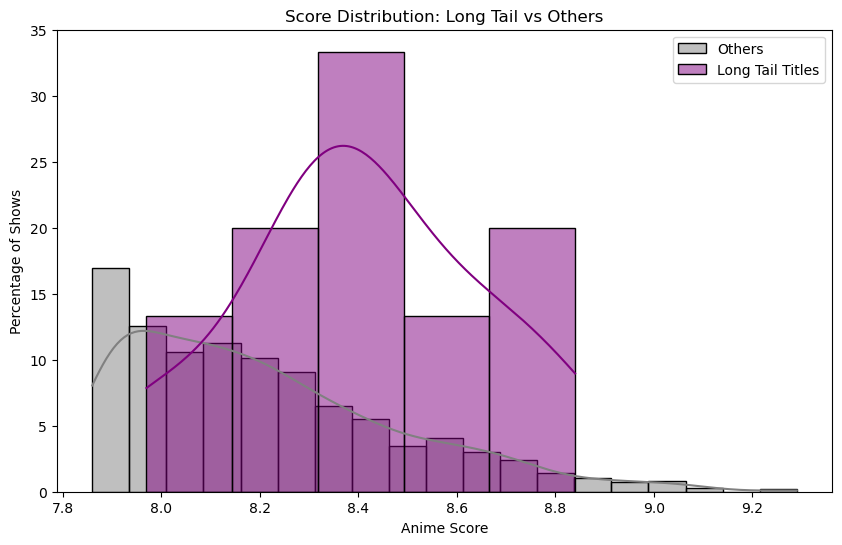

In [11]:
#[Anime DataFrame]
#Comparison of the Anime Originated Long Tail vs Others 
#Long tail titles are not too high on the score (8-8.8 range) and the percentage of shows range from many to little (not all have season 2) 
plt.figure(figsize=(10, 6))
sns.histplot(anime_df[anime_df['Long_Tail_Astudio'] == 0]['Score'], 
             color='gray', label='Others', kde=True, stat="percent")
sns.histplot(anime_df[anime_df['Long_Tail_Astudio'] == 1]['Score'], 
             color='purple', label='Long Tail Titles', kde=True, stat="percent")

plt.title('Score Distribution: Long Tail vs Others')
plt.xlabel('Anime Score')
plt.ylabel('Percentage of Shows')
plt.legend()
plt.show()

C:\Users\akoki\AppData\Local\Temp\ipykernel_17724\1940618972.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=abs_correlation.values, y=abs_correlation.index, palette='magma')


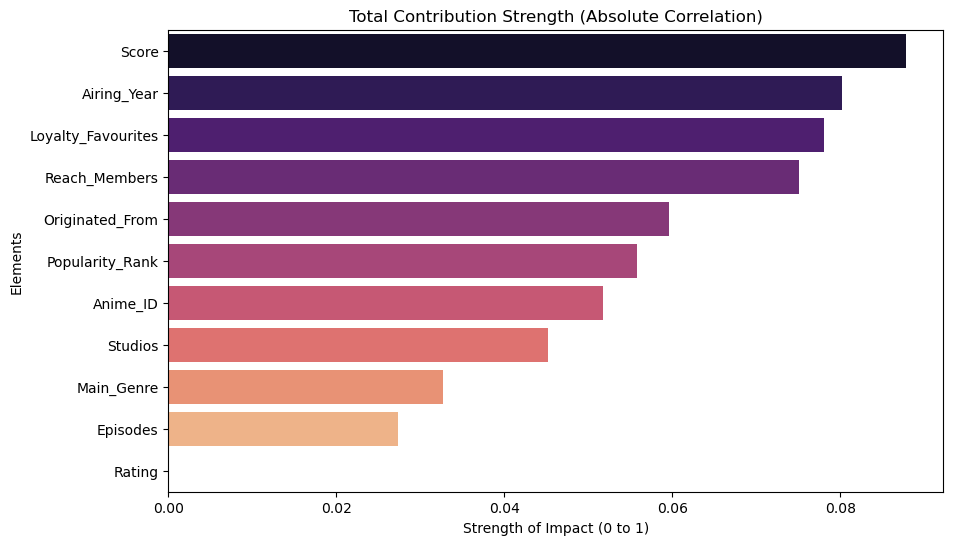

In [12]:
#[Anime DataFrame]
#Assessing what is correlated to (contributed to) Long Tail success of Anime Studio Originated IPs 
abs_correlation = correlation.drop('Long_Tail_Astudio').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=abs_correlation.values, y=abs_correlation.index, palette='magma')

plt.title("Total Contribution Strength (Absolute Correlation)")
plt.xlabel("Strength of Impact (0 to 1)")
plt.ylabel("Elements")
plt.show()

Loyalty_Favourites    1.000000
Reach_Members         0.816718
Score                 0.363517
Episodes              0.136161
Long_Tail_Astudio     0.078069
Originated_From      -0.085061
Main_Genre           -0.104499
Airing_Year          -0.106139
Anime_ID             -0.161044
Studios              -0.176491
Popularity_Rank      -0.317291
Rating                     NaN
Name: Loyalty_Favourites, dtype: float64


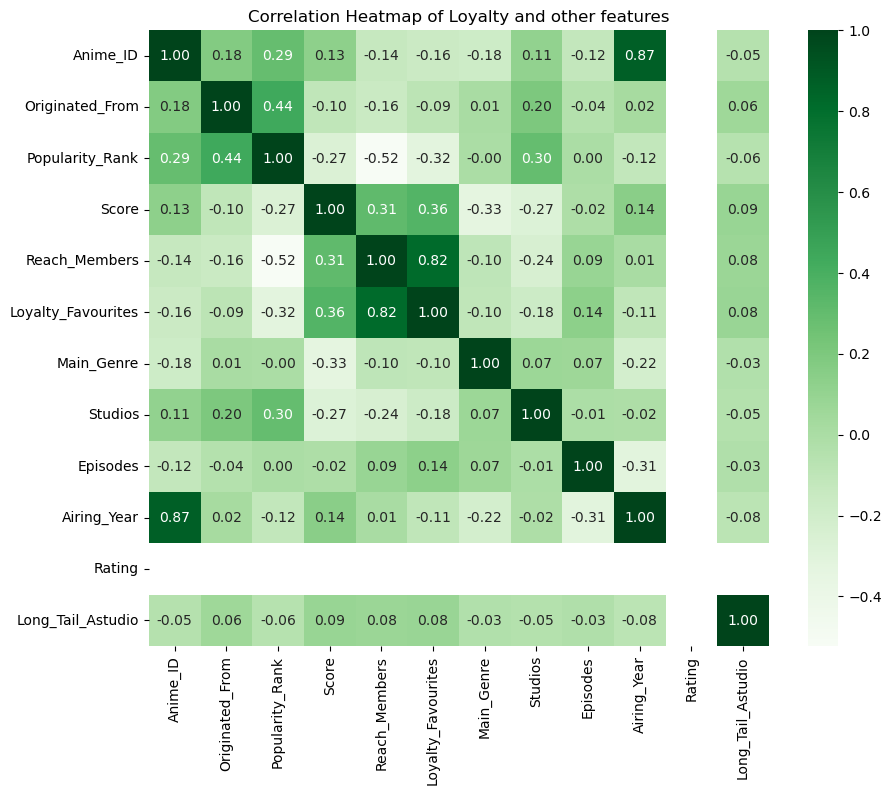

In [40]:
#[Anime DataFrame]
#Prepping for ML, trying to identify the columns that are similar 
correlation_matrix = anime_df.corr(numeric_only=True)
print(correlation_matrix['Loyalty_Favourites'].sort_values(ascending=False))
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Greens', fmt=".2f")
plt.title("Correlation Heatmap of Loyalty and other features")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

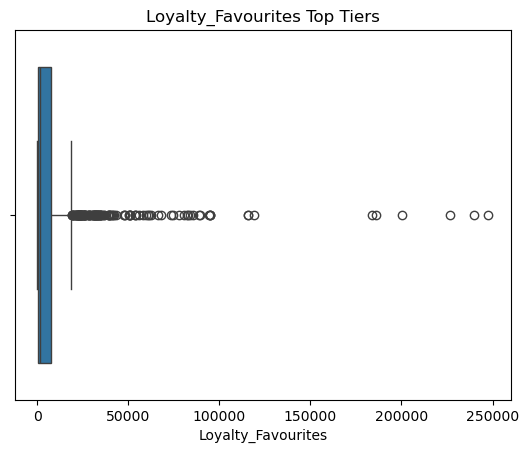

In [79]:
#[Anime DataFrame]
#Using Boxplotting to see where in range Loyalty Favourite top tier belongs, seems to be above 61K+ 
sns.boxplot(x=anime_df['Loyalty_Favourites'])
plt.title('Loyalty_Favourites Top Tiers')
plt.show

****-------------------------------------[Machine Learning Model Fitting : Anime Originated Long Tail]-------------------------------------------****






In [80]:
#[Anime DataFrame]
# Based on the above Boxplot, creating a new column with 'is_hit' with threhold of 61K+, which is about 2% of all the other data 
anime_df['is_hit'] = np.where(anime_df['Loyalty_Favourites'] >= 61000, 1, 0)
print(anime_df['is_hit'].value_counts())

is_hit
0    973
1     27
Name: count, dtype: int64


In [95]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
#1 : Separating Features from Target Column in Surpervised Machine Learning 
target = anime_df['is_hit']

features = anime_df.drop(columns=["Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites", "is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Licensors"
], errors='ignore')

#2 : Using StandardScaler, adjusted the numbers for easier learning 
scaler = StandardScaler()
feature_scaled = scaler.fit_transform(features)
feature_scaled_df = pd.DataFrame(feature_scaled, columns=features.columns)

In [96]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
#Spliting Test & Train 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [97]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
#Fitting to Random Forest Classifier to predict the Hit Makers 
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

# performance evaluation
print("--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

--- Random Forest Results ---
Accuracy: 99.00%
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       194
           1       1.00      0.67      0.80         6

    accuracy                           0.99       200
   macro avg       0.99      0.83      0.90       200
weighted avg       0.99      0.99      0.99       200



In [98]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
# Confusion Matrics Result were: 2 False Negative, 4 True Positives, we have regular ones more, so 98% is very normal as we have about 2% hit ratio 
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

--- Confusion Matrix ---
[[194   0]
 [  2   4]]


In [99]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
# Adjusting the imbalance by giving more weight to "is_hit"
clf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [100]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
# Getting the Prediction again
y_pred = clf_model.predict(X_test)

# Only Precision Rate improved but NOT recall 
print(classification_report(y_test, y_pred))

#Confusion Matrix has no change,or worse 
cm = confusion_matrix(y_test, y_pred)
cm

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       194
           1       1.00      0.67      0.80         6

    accuracy                           0.99       200
   macro avg       0.99      0.83      0.90       200
weighted avg       0.99      0.99      0.99       200



array([[194,   0],
       [  2,   4]])

In [101]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier) 
#SMOTE to balance the imbalance
smote = SMOTE(sampling_strategy='auto', random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training size: {X_train.shape[0]}")
print(f"New training size after SMOTE: {X_train_res.shape[0]}")

forest_smote_clf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
forest_smote_clf.fit(X_train_res, y_train_res)

pred_smote = forest_smote_clf.predict(X_test)

print("--- Results with SMOTE ---")
print(f"Accuracy Score: {accuracy_score(y_test, pred_smote):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_smote))


Original training size: 800
New training size after SMOTE: 1558
--- Results with SMOTE ---
Accuracy Score: 0.9700

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       194
           1       0.50      0.83      0.62         6

    accuracy                           0.97       200
   macro avg       0.75      0.90      0.80       200
weighted avg       0.98      0.97      0.97       200



In [102]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier)
#Confusion Matrix again, 1 false positive and 5 true positives 
cm = confusion_matrix(y_test, pred_smote)
cm

array([[189,   5],
       [  1,   5]])

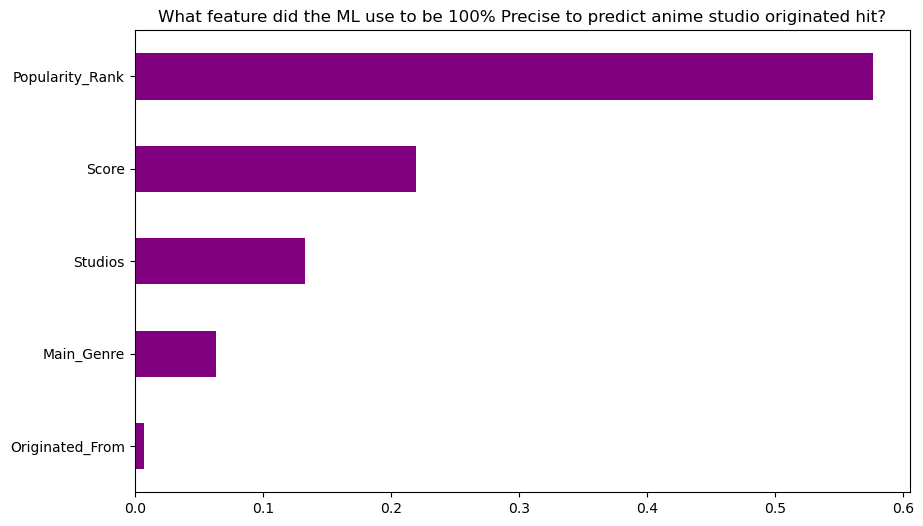

In [104]:
#[Anime DataFrame]
#Surpervised Machine Learning Trial (RandomForestClassifier)
#Which feature contribute the best to predict hit or not 
importances = pd.Series(clf_model.feature_importances_, index=features.columns)
importances.sort_values().plot(kind='barh', color='purple', figsize=(10, 6))
plt.title("What feature did the ML use to be 100% Precise to predict anime studio originated hit?")
plt.show()

****------------------------------------[Conclusion on Random Forest Classifier for Anime Originated Long Tail]-----------------------------------****
- Random Forest Classifier was a good model, but due to data imbalance of is_hit = 27, not_hit = 973, it's too easy to predict not_hit 
- SMOTE improved the Recall Macro Average from 83% to 90%, 67% to 83%, but precision reduced to 50% 

***Next Step : Add more features to increase the accuracy***
  
****----------------------------------------------------------------------------------------------------------------------------------------------****

****--------------------------------------------------------------[RAWG Game DataFrame]------------------------------------------------------****

RAWG Video Games Database API : 

The largest open video games database that includes more than 350,000 games for 50 platforms including mobiles.
Trying to identify the IPs that might have made into Game. 

In [35]:
#[Games DataFrame]
#Connecting to RAWG API with token saved on secret file 
from dotenv import load_dotenv, find_dotenv

load_dotenv(override=True)

API_KEY = os.getenv("RAWG_API_KEY")

In [36]:
#[Games DataFrame]
#looking to see whats inside of RAWG games database API  
test_response = requests.get(f"https://api.rawg.io/api/games?key={API_KEY}&page_size=1")
print(test_response.json()['results'][0].keys()) 

dict_keys(['id', 'slug', 'name', 'released', 'tba', 'background_image', 'rating', 'rating_top', 'ratings', 'ratings_count', 'reviews_text_count', 'added', 'added_by_status', 'metacritic', 'playtime', 'suggestions_count', 'updated', 'user_game', 'reviews_count', 'saturated_color', 'dominant_color', 'platforms', 'parent_platforms', 'genres', 'stores', 'clip', 'tags', 'esrb_rating', 'short_screenshots'])


In [37]:
#[Games DataFrame]
#Collecting Raw game API data 
import os
import requests
import pandas as pd
import time



game_data = []
target_count = 1000 
page = 1

print("🚀 Starting RAWG Game Data Collection...")

while len(game_data) < target_count:
    # RAWG uses &key= and &page=
    url = f"https://api.rawg.io/api/games?key={API_KEY}&page={page}&page_size=40"
    
    response = requests.get(url)

    if response.status_code == 200:
        # RAWG puts the list inside the 'results' key
        data = response.json().get('results', [])
        
        if not data:
            print("No more data available.")
            break

        for item in data:
            if len(game_data) >= target_count:
                break
            
            row = {
                'Game_ID': item.get('id'),
                'Title': item.get('name'),
                'Release_Date': item.get('released'),
                'Rating_Score': item.get('rating'),  
                'Metacritic': item.get('metacritic'),
                'Playtime_Avg': item.get('playtime'),
                'Genres': ", ".join([g['name'] for g in item.get('genres', [])]),
                'Platforms': ", ".join([p['platform']['name'] for p in item.get('platforms', [])]),
                'Ratings_Count': item.get('ratings_count'),
                'Suggestions_Count': item.get('suggestions_count'),
                'Updated_At': item.get('updated')
            }
            game_data.append(row)
        
        print(f"✅ Page {page} processed. Total: {len(game_data)}")
        page += 1
   
        time.sleep(1) 
        
    elif response.status_code == 429:
        print("⏳ Rate limited! Waiting...")
        time.sleep(10)
    else:
        print(f"❌ Error {response.status_code}. Stopping.")
        breakzzz

#Convert to DataFrame
games_df = pd.DataFrame(game_data)
print("📦 Collection Complete!")

🚀 Starting RAWG Game Data Collection...
✅ Page 1 processed. Total: 40
✅ Page 2 processed. Total: 80
✅ Page 3 processed. Total: 120
✅ Page 4 processed. Total: 160
✅ Page 5 processed. Total: 200
✅ Page 6 processed. Total: 240
✅ Page 7 processed. Total: 280
✅ Page 8 processed. Total: 320
✅ Page 9 processed. Total: 360
✅ Page 10 processed. Total: 400
✅ Page 11 processed. Total: 440
✅ Page 12 processed. Total: 480
✅ Page 13 processed. Total: 520
✅ Page 14 processed. Total: 560
✅ Page 15 processed. Total: 600
✅ Page 16 processed. Total: 640
✅ Page 17 processed. Total: 680
✅ Page 18 processed. Total: 720
✅ Page 19 processed. Total: 760
✅ Page 20 processed. Total: 800
✅ Page 21 processed. Total: 840
✅ Page 22 processed. Total: 880
✅ Page 23 processed. Total: 920
✅ Page 24 processed. Total: 960
✅ Page 25 processed. Total: 1000
📦 Collection Complete!


In [56]:
#[Games Dataframe]
#checking whats inside RAWG API 
games_df.head(5)
games_df.to_csv('RAWG_dataset.csv', index=False)
print("Data saved")
games_df.head(3)

Data saved


,Game_ID,Title,Release_Date,Rating_Score,Metacritic,Playtime_Avg,Genres,Platforms,Ratings_Count,Suggestions_Count,Updated_At
0,3498,Grand Theft Auto V,2013-09-17,4.47,92.0,74,Action,"PlayStation 5, Xbox Series S/X, PlayStation 3,...",7307,446,2026-01-22T06:17:45
1,3328,The Witcher 3: Wild Hunt,2015-05-18,4.64,92.0,43,"Action, RPG","PlayStation 5, Xbox Series S/X, macOS, PlaySta...",7117,688,2026-01-19T21:37:58
2,4200,Portal 2,2011-04-18,4.58,95.0,11,"Shooter, Puzzle","PlayStation 3, PC, Xbox 360, Linux, macOS, Xbo...",6042,567,2026-01-22T06:44:30
3,4291,Counter-Strike: Global Offensive,2012-08-21,3.57,81.0,64,Shooter,"PC, Linux, Xbox 360, PlayStation 3",3613,607,2026-01-15T12:59:32
4,5286,Tomb Raider (2013),2013-03-05,4.06,86.0,10,Action,"PlayStation 3, Xbox 360, macOS, PC",4066,660,2026-01-19T05:58:05
...,...,...,...,...,...,...,...,...,...,...,...
995,10606,Mirage: Arcane Warfare,2017-05-23,2.17,74.0,3,"Action, Indie",PC,177,631,2025-11-04T20:30:23
996,5426,Crash Bandicoot 3: Warped,1998-10-31,4.34,91.0,5,"Action, Platformer",PlayStation,650,396,2026-01-05T19:10:12
997,45109,Maneater,2020-05-22,3.43,68.0,4,"Action, Adventure, RPG, Indie","PlayStation 5, PlayStation 4, PC, Xbox One, Ni...",259,534,2026-01-03T10:30:26
998,12322,Emily is Away,2015-11-20,3.58,NaN,1,"Adventure, Simulation, Casual, Indie","Linux, PC, macOS",436,76,2026-01-04T01:33:58


****-------------------------------------------------------------[Twitch Game API]---------------------------------------------------------------****

In [39]:
#[Games Dataframe]
#Loading Twitch Game API IGDB 

load_dotenv()

client_id = os.getenv("client_id")
client_secret = os.getenv("client_secret")

#askig for authorisation 
auth_url = "https://id.twitch.tv/oauth2/token"
auth_params = {
    'client_id': client_id,
    'client_secret': client_secret,
    'grant_type': 'client_credentials'
}

response = requests.post(auth_url, params=auth_params)

if response.status_code == 200:
    access_token = response.json().get('access_token')
    print("✅ Handshake Successful!")
    print(f"Your temporary Access Token starts with: {access_token[:8]}...")
else:
    print(f"❌ Handshake Failed: {response.status_code}")
    print(response.json())

✅ Handshake Successful!
Your temporary Access Token starts with: fq9mdqgz...


In [40]:
#[Game DataFrame]
# The header must contain BOTH the Client-ID and the Authorization token
headers = {
    'Client-ID': client_id,
    'Authorization': f'Bearer {access_token}'
}

# Example: Get the top 5 games with their release dates
# IGDB uses a special query language in the "data" field
query = "fields name, first_release_date; limit 5;"
igdb_response = requests.post("https://api.igdb.com/v4/games", headers=headers, data=query)

print(igdb_response.json())

[{'id': 350392, 'name': 'Rival Species'}, {'id': 30492, 'first_release_date': 1483660800, 'name': 'Hearts of Chaos'}, {'id': 339266, 'first_release_date': 1692057600, 'name': 'Power Guy World'}, {'id': 371776, 'name': 'Born for the Light: Wavelength Radiant Collapse'}, {'id': 376989, 'first_release_date': 1193702400, 'name': 'Dune Buggy'}]


In [41]:
#[Games Dataframe]
# Reading Metadatas to see which parameters to read for the dataframe, Twitch version is more extensive 
metadata_url = "https://api.igdb.com/v4/games/meta"
metadata_response = requests.get(metadata_url, headers=headers)
print(metadata_response.json())

['age_ratings', 'aggregated_rating', 'aggregated_rating_count', 'alternative_names', 'artworks', 'bundles', 'category', 'collection', 'cover', 'created_at', 'dlcs', 'expansions', 'external_games', 'first_release_date', 'follows', 'franchise', 'franchises', 'game_engines', 'game_modes', 'genres', 'hypes', 'involved_companies', 'keywords', 'multiplayer_modes', 'name', 'parent_game', 'platforms', 'player_perspectives', 'rating', 'rating_count', 'release_dates', 'screenshots', 'similar_games', 'slug', 'standalone_expansions', 'status', 'storyline', 'summary', 'tags', 'themes', 'total_rating', 'total_rating_count', 'updated_at', 'url', 'version_parent', 'version_title', 'videos', 'websites', 'checksum', 'remakes', 'remasters', 'expanded_games', 'ports', 'forks', 'language_supports', 'game_localizations', 'collections', 'game_status', 'game_type']


In [44]:
#[Games Dataframe]
#Loading Twitch IGDB API into dataframe 
# Configuration
target_count = 1000
limit = 50  
offset = 0
twitch_data = []

# Ensure your headers are defined before this block
# headers = {'Client-ID': 'your_id', 'Authorization': 'Bearer your_token'}

print("🚀 Starting Clean & Broad IGDB Data Collection (Excluding Erotica)...")

while len(twitch_data) < target_count:
    # Logic: 
    # 1. total_rating_count != n (ensures the game has feedback/popularity)
    # 2. genres != (35) (EXCLUDES Erotica)
    # 3. keywords = (24) OR keywords = (112) etc. (Optional: add keywords like 'cel shaded' if you want that look)
    
    query = f"""
    fields name, first_release_date, category, status,
           game_engines.name, game_modes.name, genres.name, platforms.name,
           involved_companies.company.name, involved_companies.developer, involved_companies.publisher,
           keywords.name, storyline, summary, themes.name,
           total_rating, total_rating_count, follows, hypes, player_perspectives.name;
    
    where total_rating_count != n & genres != (35);
    sort total_rating_count desc;
    limit {limit};
    offset {offset};
    """
    
    response = requests.post("https://api.igdb.com/v4/games", headers=headers, data=query)

    if response.status_code == 200:
        data = response.json()
        
        if not data:
            print("No more data found.")
            break

        for item in data:
            row = {
                'Title': item.get('name'),
                'Release_Date': item.get('first_release_date'),
                'Genres': ", ".join([g['name'] for g in item.get('genres', [])]),
                'Themes': ", ".join([t['name'] for t in item.get('themes', [])]),
                'Developer': ", ".join([c['company']['name'] for c in item.get('involved_companies', []) if c.get('developer')]),
                'Publisher': ", ".join([c['company']['name'] for c in item.get('involved_companies', []) if c.get('publisher')]),
                'Total_Rating': item.get('total_rating'),
                'Rating_Count': item.get('total_rating_count'),
                'Summary': item.get('summary')
            }
            twitch_data.append(row)
        
        print(f"Progress: {len(twitch_data)}/{target_count} titles (Offset: {offset})")
        offset += limit
        time.sleep(0.35) # Safe rate limit
        
    elif response.status_code == 429:
        print("Rate limited! Waiting 15s...")
        time.sleep(15)
    else:
        print(f"Error {response.status_code}: {response.text}")
        break

twitch_df = pd.DataFrame(twitch_data)
print(f"Collection Complete! Final Shape: {twitch_df.shape}")

🚀 Starting Clean & Broad IGDB Data Collection (Excluding Erotica)...
✅ Progress: 50/1000 titles (Offset: 0)
✅ Progress: 100/1000 titles (Offset: 50)
✅ Progress: 150/1000 titles (Offset: 100)
✅ Progress: 200/1000 titles (Offset: 150)
✅ Progress: 250/1000 titles (Offset: 200)
✅ Progress: 300/1000 titles (Offset: 250)
✅ Progress: 350/1000 titles (Offset: 300)
✅ Progress: 400/1000 titles (Offset: 350)
✅ Progress: 450/1000 titles (Offset: 400)
✅ Progress: 500/1000 titles (Offset: 450)
✅ Progress: 550/1000 titles (Offset: 500)
✅ Progress: 600/1000 titles (Offset: 550)
✅ Progress: 650/1000 titles (Offset: 600)
✅ Progress: 700/1000 titles (Offset: 650)
✅ Progress: 750/1000 titles (Offset: 700)
✅ Progress: 800/1000 titles (Offset: 750)
✅ Progress: 850/1000 titles (Offset: 800)
✅ Progress: 900/1000 titles (Offset: 850)
✅ Progress: 950/1000 titles (Offset: 900)
✅ Progress: 1000/1000 titles (Offset: 950)
📦 Collection Complete! Final Shape: (1000, 9)


In [388]:
#[Games Dataframe]
#Searching for top 27 
famous_ips = 'one piece|naruto|bleach|gundam|demon slayer|jujutsukaisen|Evangelion|Cowboy Bebop|Violet Evergarden|Attack on Titan|My Hero Academia|Bleach|JoJo|That Time I Got Reincarnated as a Slim|Re:Zero|Fate/Grandorder|One Punch Man|Fullmetal Alchemist|Death Note|HunterxHunter|Steins;Gate|No Game No Life|Code Geass|Mob Psycho 100|Your lie in April|Angel Beats!|Haikyuu!!|Promised Neverland|konosuba|Parasyte'
tw_df = twitch_df[
    (twitch_df['Summary'].str.contains(famous_ips, case=False, na=False)) & 
    (~twitch_df['Themes'].str.contains('erotic', case=False, na=False))
]

# 3. Sort
top_clean_games = tw_df.sort_values(by='Total_Rating', ascending=False)
tw_df
tw_df.to_csv('twitch_filtered_dataset.csv', index=False)
print("Data saved")
tw_df

Data saved


,Title,Release_Date,Genres,Themes,Developer,Publisher,Total_Rating,Rating_Count,Summary
188,Halo 3,1190678400,Shooter,"Action, Science fiction, Sandbox, Warfare",Bungie,Microsoft Game Studios,88.087008,800,Halo 3 is a shooter game where players primari...
611,Steins;Gate,1255564800,"Adventure, Visual Novel","Science fiction, Survival, Historical, Mystery","MAGES., NITRO PLUS, 5pb.","PQube, JAST USA, MAGES., Kadokawa Shoten, 5pb.",86.645500,286,Steins;Gate is a Japanese visual novel develop...
961,Naruto Shippuden: Ultimate Ninja Storm 4,1454544000,"Fighting, Adventure",Action,CyberConnect2,Bandai Namco Entertainment,76.324208,193,Experience the exhilarating full-adventure Nar...


****-----------------------------------------------------[Google Play CSV from Kaggle]----------------------------------------------------------****

In [387]:
#[Games Dataframe]
#Reading Google Play Kaggle CSV 
gp_df = pd.read_csv("games_info.csv")

In [385]:
#[Games Dataframe]
#Trying to assess if there is any tie up that happened between the famous IP & global gamees 
#famous_ips = 'one piece|naruto|dragon ball|bleach|gundam|demon slayer|pokemon|digimon|yu-gi-oh|jujutsukaisen|Evangelion|Cowboy Bebop|Violet Evergarden|Attack on Titan'
clean_gpdf = gp_df[
    (gp_df['description'].str.contains(famous_ips, case=False, na=False)) 
]

# 3. Sort
top_clean_games = clean_gpdf.sort_values(by='downloads', ascending=False)
clean_gpdf
clean_gpdf.to_csv('Google_Play_filtered_dataset.csv', index=False)
print("Data saved")
clean_gpdf

Data saved


,game_id,game_name,description,score,ratings_count,downloads,content_rating,section,categories
321,322,Blood Strike - FPS for all,Blood Strike x Attack on Titan Collaboration S...,4.3,760000,50000000,Teen,Stylized games,"Action, Shooter, Tactical shooter, Casual, Mul..."


In [386]:
#[Games Dataframe]
#Raw Games filtered by famous IPs 
rawg_df = games_df[
    (games_df['Title'].str.contains(famous_ips, case=False, na=False))]

# Sort
top_clean_raw_games = rawg_df.sort_values(by='Suggestions_Count', ascending=False)
rawg_df.to_csv('rawg_filtered_dataset.csv', index=False)
print("Data saved")
rawg_df

Data saved


,Game_ID,Title,Release_Date,Rating_Score,Metacritic,Playtime_Avg,Genres,Platforms,Ratings_Count,Suggestions_Count,Updated_At
930,2828,NARUTO SHIPPUDEN: Ultimate Ninja STORM 4,2016-02-04,4.02,80.0,8,"Action, Fighting","PC, Xbox One, PlayStation 4",499,524,2025-12-14T19:15:38


****-----------------------------------------------------------[Layer Website WebScraping]-------------------------------------------------------****

To assess the globalisation power of the IP, looking at Online Games collaboration data in English Speaking markets. 
The profit mergin of this is about 10-30% and bigger than the Merch, although could be shorter period than Merch (6-12mos)

- https://www.layerlicensing.com/

In [15]:
#[Games DataFrame]
#Web Scraping of a Website that list collaboration with games liveops 

def scrape_all_collabs(max_pages=13):
    base_url = "https://www.layerlicensing.com/collab-tracker"
    all_data = []
    
    page_param = "d14182ed_page" 
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    }

    for page in range(1, max_pages + 1):
        print(f"Fetching Page {page}...")
        params = {page_param: page}
        
        try:
            response = requests.get(base_url, headers=headers, params=params, timeout=10)
            if response.status_code != 200:
                print(f"Finished: Page {page} not found.")
                break
            
            soup = BeautifulSoup(response.text, 'html.parser')
            
            items = soup.find_all('div', class_='w-dyn-item')
            
            if not items:
                print("No more items found. Stopping.")
                break
            
            for item in items:
             
                name = item.find('h3').get_text(strip=True) if item.find('h3') else "N/A"
                
                all_data.append({
                    "Page": page,
                    "Collaboration": name,
                    "Raw_Text": item.get_text(separator=" | ", strip=True)
                })
                
            time.sleep(1.5)
            
        except Exception as e:
            print(f"Error on page {page}: {e}")
            break

    return pd.DataFrame(all_data)

# Run for as many pages as you need
df = scrape_all_collabs(max_pages=20)

# Save the final result
df.to_csv("collab_tracker_full.csv", index=False)
print(f"Success! Scraped {len(df)} total collaborations.")

Fetching Page 1...
Fetching Page 2...
Fetching Page 3...
Fetching Page 4...
Fetching Page 5...
Fetching Page 6...
Fetching Page 7...
Fetching Page 8...
Fetching Page 9...
Fetching Page 10...
Fetching Page 11...
Fetching Page 12...
Fetching Page 13...
Fetching Page 14...
Fetching Page 15...
Fetching Page 16...
Fetching Page 17...
Fetching Page 18...
Fetching Page 19...
Fetching Page 20...
Success! Scraped 660 total collaborations.


In [16]:
liveops_df = df
liveops_df.head(3)

,Page,Collaboration,Raw_Text
0,1,N/A,"The Sims 4 x Coach | January 12, 2026 | Luxury..."
1,1,N/A,"PUBG Mobile x Peaky Blinders | January 12, 202..."
2,1,N/A,"Fortnite x South Park | January 9, 2026 | Film..."


In [17]:
#Re-creating the list 
top_ips_list = """one piece|naruto|bleach|gundam|demon slayer|jujutsukaisen|Evangelion|Cowboy Bebop|Violet Evergarden|Attack on Titan|My Hero Academia|Bleach|JoJo|That Time I Got Reincarnated as a Slim|Re:Zero|Fate/Grandorder|One Punch Man|Fullmetal Alchemist|Death Note|HunterxHunter|Steins;Gate|No Game No Life|Code Geass|Mob Psycho 100|Your lie in April|Angel Beats!|Haikyuu!!|Promised Neverland|konosuba|Parasyte|Attack on Titan | Death Note | Fullmetal Alchemist: Brotherhood | One Punch Man | Demon Slayer | Hunter x Hunter (2011) | Naruto | Kimi no Na wa. | Attack on Titan Season 2 | Jujutsu Kaisen | Steins;Gate | Naruto: Shippuuden | My Hero Academia 2nd Season | One Piece | Attack on Titan Season 3 | Koe no Katachi | Attack on Titan Season 3 Part 2 | No Game No Life | Code Geass: Hangyaku no Lelouch | Re:Zero kara Hajimeru Isekai Seikatsu | Shigatsu wa Kimi no Uso | My Hero Academia 3rd Season | Toradora! | Noragami | Mob Psycho 100 | Erased | Attack on Titan: The Final Season | Assassination Classroom | Angel Beats! | Bleach | Haikyuu!! | The Promised Neverland | KonoSubaii Sekai ni Shukufuku wo! | Cowboy Bebop | Parasyte | Spirited Away  | Shinseiki Evangelion | Violet Evergarden | Code Geass: Hangyaku no Lelouch R2 | Rascal Does Not Dream | Dr. Stone | Kaguya-sama wa Kokurasetai: Tensai-tachi no Renai Zunousen | Death Parade | Chainsaw Man | Black Clover | Spy x Family | Kill la Kill | JoJo no Kimyou na Bouken (TV) | Vinland Saga | Demon Slayer Movie: Mugen Ressha-hen | Gurren Lagann | The Rising of the Shield Hero | Overlord | Food Wars! | Psycho-Pass | Demon Slayer: Yuukaku-hen | Mob Psycho 100 II | Ano Hi Mita Hana no Namae wo Bokutachi wa Mada Shiranai. | KonoSuba 2 | That Time I Got Reincarnated as a Slime | Horimiya | Fate/Zero | Assassination Classroom 2nd Season | Haikyuu!! Second Season | My Youth Romantic Comedy Is Wrong, as I Expected | Fullmetal Alchemist | Noragami Aragoto | Mushoku Tensei | Made in Abyss | Attack on Titan: The Final Season Part 2 | Clannad | Durarara!! | Bakemonogatari | Kaguya-sama: Love Is War? Tensai-tachi no Renai Zunousen | Howl's moving castle | Hyouka | Puella Magi Madoka Magica | Spirited Away  | Dororo | JoJo no Kimyou na Bouken Part 3: Stardust Crusaders | Samurai Champloo | Kaichou wa Maid-sama! | Jujutsu Kaisen 2nd Season | Kobayashi-san Chi no Maid Dragon | Frieren | Sakura-sou no Pet na Kanojo | Dragon Ball Z | Haikyuu!! Karasuno Koukou vs. Shiratorizawa Gakuen Koukou | Kuroko no Basket | Monster | Sono Bisque Doll wa Koi wo Suru | Clannad: After Story | Zankyou no Terror | Re:Zero kara Hajimeru Isekai Seikatsu 2nd Season | JoJo no Kimyou na Bouken Part 4: Diamond wa Kudakenai | Saiki Kusuo no Ψ-nan | JoJo no Kimyou na Bouken Part 3: Stardust Crusaders - Egypt-hen | Ouran Koukou Host Club | Jujutsu Kaisen 0 Movie | Food Wars!: Ni no Sara | Fate/Zero 2nd Season | Dr. Stone: Stone Wars | Log Horizon | Fate/stay night: Unlimited Blade Works | Tonari no Totoro | My Youth Romantic Comedy Is Wrong, as I Expected Zoku | JoJo no Kimyou na Bouken Part 5: Ougon no Kaze | Gintama | Dragon Ball | ReLIFE | K-On! | Magi: The Labyrinth of Magic | Tenki no Ko | Spy x Family Part 2 | Black Lagoon | Mushoku Tensei Part 2 | Kimi no Suizou wo Tabetai | That Time I Got Reincarnated as a Slime 2nd Season | Ore dake Level Up na Ken | Wotaku ni Koi wa Muzukashii | Kaguya-sama: Love Is War: Ultra Romantic | Demon Slayer: Katanakaji no Sato-hen | Kimi ni Todoke | Re:Zero kara Hajimeru Isekai Seikatsu 2nd Season Part 2 | Haikyuu!! To the Top | Food Wars!: San no Sara | Youjo Senki | Shinseiki Evangelion Movie: Air/Magokoro wo, Kimi ni | Plastic Memories | [Oshi no Ko] | Cyberpunk: Edgerunners | Mahoutsukai no Yome | Hellsing Ultimate | Darker than Black: Kuro no Keiyakusha | Overlord III | Fumetsu no Anata e | Nichijou | Baccano! | Banana Fish | Demon Slayer: Mugen Ressha-hen | 86 | Yuri!!! on Ice | Steins;Gate 0 | Bungou Stray Dogs 2nd Season | Akira | No Game No Life: Zero | Fruits Basket 1st Season | Akatsuki no Yona | Kuroko no Basket 2nd Season | Haikyuu!! To the Top Part 2 | Dandadan | Fate/stay night: Unlimited Blade Works 2nd Season | Great Teacher Onizuka | Jigokuraku | Mushishi | Magi: The Kingdom of Magic | That Time I Got Reincarnated as a Slime 2nd Season Part 2 | Grand Blue | FLCL | Serial Experiments Lain | Danshi Koukousei no Nichijou | KonoSubaii Sekai ni Shukufuku wo! Movie: Kurenai Densetsu | Hotarubi no Mori e | Blue Lock | Ookami to Koushinryou | Ookami Kodomo no Ame to Yuki | InuYasha | Higurashi no Naku Koro ni | Kage no Jitsuryokusha ni Naritakute! | Mob Psycho 100 III | Attack on Titan: The Final Season - Kanketsu-hen | Toki wo Kakeru Shoujo | Trigun | Kuroko no Basket 3rd Season | NHK ni Youkoso! | Vinland Saga Season 2 | Shinsekai yori | My Youth Romantic Comedy Is Wrong, as I Expected Kan | Seishun Buta Yarou wa Yumemiru Shoujo no Yume wo Minai | Perfect Blue | 5-toubun no Hanayome ∬ | My Hero Academia 6th Season | Kusuriya no Hitorigoto | Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu e 2nd Season | Nisemonogatari | Food Wars!: San no Sara - Tootsuki Ressha-hen | Nana | Bocchi the Rock! | Hotaru no Haka | Kenpuu Denki Berserk | Yofukashi no Uta | Yuu☆Yuu☆Hakusho | K-On!! | Ousama Ranking | Great Pretender | Demon Slayer: Hashira Geiko-hen | Mushoku Tensei II: Isekai Ittara Honki Dasu | Ore dake Level Up na Ken Season 2: Arise from the Shadow | Ore Monogatari!! | D.Gray-man | 3-gatsu no Lion | Kamisama Hajimemashita | Monogatari Series: Second Season | Violet Evergarden Movie | Saiki Kusuo no Ψ-nan 2 | Barakamon | Ergo Proxy | Bungou Stray Dogs 3rd Season | Kaijuu 8-gou | Koukaku Kidoutai | Gintama° | Bleach: Sennen Kessen-hen | Hajime no Ippo | Summertime Render | Bakuman. | Spy x Family Season 2 | Majo no Takkyuubin | Suzumiya Haruhi no Shoushitsu | Gake no Ue no Ponyo | Lovely★Complex | Hunter x Hunter | Steins;Gate Movie: Fuka Ryouiki no Déjà vu | Nagi no Asu kara | Given | Zetsuen no Tempest | My Hero Academia the Movie 2: Heroes:Rising | 86 Part 2 | SK∞ | Overlord IV | Dorohedoro | Vanitas no Karte | Drifters | Tengoku Daimakyou | Evangelion Movie 1: Jo | Gintama' | Kobayashi-san Chi no Maid Dragon S | Paprika | Vivy: Fluorite Eye's Song | Gosick | JoJo no Kimyou na Bouken Part 6: Stone Ocean | Katanagatari | Tsuki ga Kirei | Evangelion Movie 2: Ha | Dr. Stone: New World | Nekomonogatari: Kuro | Katekyou Hitman Reborn! | Natsume Yuujinchou | Lycoris Recoil | Fruits Basket 2nd Season | Kizumonogatari I: Tekketsu-hen | Black Lagoon: The Second Barrage | Attack on Titan: Kuinaki Sentaku | Dungeon Meshi | Fruits Basket: The Final | Hinamatsuri | Sora yori mo Tooi Basho | Komi-san wa, Comyushou desu. 2nd Season | Kimi ni Todoke 2nd Season | Mushoku Tensei II: Isekai Ittara Honki Dasu Part 2 | Summer Wars | Megalo Box | Yuru Camp△ | KonoSubaii Sekai ni Shukufuku wo! 3 | Tenkuu no Shiro Laputa | Asobi Asobase | Made in Abyss Movie 3: Fukaki Tamashii no Reimei | Made in Abyss: Retsujitsu no Ougonkyou | Usagi Drop | Rurouni Kenshin: Meiji Kenkaku Romantan | Ookami to Koushinryou II | Higurashi no Naku Koro ni Kai | Josee to Tora to Sakana-tachi | Kage no Jitsuryokusha ni Naritakute! 2nd Season | Houseki no Kuni | Durarara!!x2 Shou | Fate/stay night Movie: Heaven's Feel - I. Presage Flower | Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu e 3rd Season | Owarimonogatari | Kizumonogatari III: Reiketsu-hen | Hibike! Euphonium | Attack on Titan OVA | Odd Taxi | Yuukoku no Moriarty | Dandadan 2nd Season | Chihayafuru | [Oshi no Ko] 2nd Season | Yojouhan Shinwa Taikei | Sayonara no Asa ni Yakusoku no Hana wo Kazarou | Suzume no Tojimari | Kizumonogatari II: Nekketsu-hen | Cardcaptor Sakura | Violet Evergarden Gaiden: Eien to Jidou Shuki Ningyou | Re:Zero kara Hajimeru Isekai Seikatsu 3rd Season | Steins;Gate: Oukoubakko no Poriomania | Shirobako | Shiguang Dailiren | Kamisama Hajimemashita◎ | Dragon Ball Super: Broly | Koukyoushihen Eureka Seven | Kusuriya no Hitorigoto 2nd Season | Golden Boy | Non Non Biyori | Bakemono no Ko | Hanamonogatari | My Hero Academia 7th Season | Golden Kamuy | Horimiya: Piece | Tsukimonogatari | ReLIFE: Kanketsu-hen | Shangri-La Frontier: Kusoge Hunter, Kamige ni Idoman to su | Kuroshitsuji: Book of Circus | 3-gatsu no Lion 2nd Season | Ping Pong the Animation | Owarimonogatari 2nd Season | Initial D First Stage | Fate/stay night Movie: Heaven's Feel - II. Lost Butterfly | Sono Bisque Doll wa Koi wo Suru Season 2 | Boku no Kokoro no Yabai Yatsu | Tamako Love Story | Rainbow: Nisha Rokubou no Shichinin | Koukaku Kidoutai: Stand Alone Complex | Redline | Durarara!!x2 Ten | Shin Evangelion Movie:|| | Azumanga Daiou The Animation | Mahou Shoujo Madoka★Magica Movie 3: Hangyaku no Monogatari | Gachiakuta | Sakamichi no Apollon | Toaru Kagaku no Railgun S | Dr. Stone: New World Part 2 | Kaze no Tani no Nausicaä | Kami nomi zo Shiru Sekai II | Cowboy Bebop: Tengoku no Tobira | KonoSubaii Sekai ni Shukufuku wo! 2: KonoSubaii Geijutsu ni Shukufuku wo! | Mimi wo Sumaseba | Durarara!!x2 Ketsu | Fate/stay night Movie: Heaven's Feel - III. Spring Song | Kaoru Hana wa Rin to Saku | Bleach: Sennen Kessen-hen - Ketsubetsu-tan | Shoujo Shuumatsu Ryokou | Karigurashi no Arrietty | Space☆Dandy | Gyakkyou Burai Kaiji: Ultimate Survivor | Akagami no Shirayuki-hime 2nd Season | Kaze Tachinu | Yagate Kimi ni Naru | Dr. Stone: Ryuusui | Meitantei Conan | Gakuen Babysitters | Chainsaw Man Movie: Reze-hen | Beck | Bakuman. 2nd Season | Violet Evergarden: Kitto "Ai" wo Shiru Hi ga Kuru no Darou | Eizouken ni wa Te wo Dasu na! | Mairimashita! Iruma-kun 2nd Season | Kami nomi zo Shiru Sekai: Megami-hen | Kaguya-sama: Love Is War: First Kiss wa Owaranai | Mononoke | Honzuki no Gekokujou: Shisho ni Naru Tame ni wa Shudan wo Erandeiraremasen | Ballroom e Youkoso | Karakai Jouzu no Takagi-san 2 | Ginga Eiyuu Densetsu | Gintama': Enchousen | Phantom: Requiem for the Phantom | K-On! Movie | Stranger: Mukou Hadan | Bungou Stray Dogs 4th Season | Kakushigoto | Kino no Tabi: The Beautiful World | Bakuman. 3rd Season | Hanasaku Iroha | Kono Oto Tomare! | Buddy Daddies | Fate/stay night: Unlimited Blade Works Prologue | Gintama. | xxxHOLiC | School Rumble | Kuroko no Basket Movie 4: Last Game | Code Geass: Fukkatsu no Lelouch | Kanata no Astra | Vanitas no Karte Part 2 | Frieren 2nd Season | JoJo no Kimyou na Bouken Part 6: Stone Ocean Part 2 | Skip to Loafer | Slam Dunk | Yubisaki to Renren | Kaze ga Tsuyoku Fuiteiru | Fumetsu no Anata e Season 2 | Nodame Cantabile | Omoide no Marnie | Shelter (Music) | Haibane Renmei | Demon Slayer Movie 1: Mugenjou-hen - Akaza Sairai | Paripi Koumei | Black Lagoon: Roberta's Blood Trail | Tokyo Godfathers | Mushishi Zoku Shou | Youjo Senki Movie | Shijou Saikyou no Deshi Kenichi | Hajime no Ippo: New Challenger | Clannad: Mou Hitotsu no Sekai, Tomoyo-hen | Sakasama no Patema | Mawaru Penguindrum | Make Heroine ga Oosugiru! | Tokyo Magnitude 8.0 | One Piece Film: Z | Shouwa Genroku Rakugo Shinjuu | Gin no Saji | Bungou Stray Dogs: Dead Apple | Full Metal Panic? Fumoffu | Ao no Hako | Fate/Grand Order: Zettai Majuu Sensen Babylonia | InuYasha: Kanketsu-hen | Promare | Spy x Family Season 3 | Chuunibyou demo Koi ga Shitai! Movie: Take On Me | Mahoutsukai no Yome: Hoshi Matsu Hito | Jujutsu Kaisen: Shimetsu Kaiyuu - Zenpen | Boku no Kokoro no Yabai Yatsu 2nd Season | Hajime no Ippo: Rising | Doukyuusei | Rurouni Kenshin: Meiji Kenkaku Romantan - Tsuioku-hen | Kyoukai no Kanata Movie 2: I'll Be Here - Mirai-hen | Mushishi Zoku Shou 2nd Season | Kanon (2006) | Yuukoku no Moriarty Part 2 | Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka IV: Shin Shou - Yakusai-hen | Steins;Gate: Kyoukaimenjou no Missing Link - Divide By Zero | Skip Beat! | Dr. Stone: Science Future | JoJo no Kimyou na Bouken Part 6: Stone Ocean Part 3 | Hachimitsu to Clover | Romantic Killer | Sword Art Online: Progressive Movie - Hoshi Naki Yoru no Aria | Kurenai no Buta | Bleach: Sennen Kessen-hen - Soukoku-tan | Planetes | One Piece Film: Strong World | Takopii no Genzai | Kokoro Connect: Michi Random | Full Metal Panic! The Second Raid | My Youth Romantic Comedy Is Wrong, as I Expected Zoku OVA | Natsume Yuujinchou San | Kuroshitsuji: Book of Murder | Kidou Senshi Gundam: Tekketsu no Orphans | Darker than Black: Kuro no Keiyakusha Gaiden | Gankutsuou | Kimi wa Houkago Insomnia | Jigokuraku 2nd Season | Zoku Natsume Yuujinchou | Chi. Chikyuu no Undou ni Tsuite | Natsume Yuujinchou Shi | Hikaru ga Shinda Natsu | Toaru Kagaku no Railgun T | Diamond no Ace | Black Clover: Mahou Tei no Ken | Working!!! | Kuragehime | Given Movie 1 | Gintama Movie 2: Kanketsu-hen - Yorozuya yo Eien Nare | Initial D Second Stage | My Hero Academia: Final Season | Kaguya-hime no Monogatari | Paradise Kiss | Kingdom | One Outs | Ookami to Koushinryou: Merchant Meets the Wise Wolf | Hibike! Euphonium 2 | Mo Dao Zu Shi | Kara no Kyoukai Movie 5: Mujun Rasen | Chihayafuru 2 | Ao Ashi | Death Billiards | Yuru Camp△ Season 2 | Bungou Stray Dogs 5th Season | Zoku Owarimonogatari | Honzuki no Gekokujou: Shisho ni Naru Tame ni wa Shudan wo Erandeiraremasen 2nd Season | One Piece Film: Gold | Shangri-La Frontier: Kusoge Hunter, Kamige ni Idoman to su 2nd Season | Yowamushi Pedal | Saiki Kusuo no Ψ-nan: Ψ-shidou-hen | Saiki Kusuo no Ψ-nan: Kanketsu-hen | Berserk: Ougon Jidai-hen III - Kourin | Maoujou de Oyasumi | Shoujo Kakumei Utena | Kara no Kyoukai Movie 3: Tsuukaku Zanryuu | Koukaku Kidoutai: Stand Alone Complex 2nd GIG | Pluto | Natsu e no Tunnel, Sayonara no Deguchi | Vampire Hunter D (2000) | Spy x Family Movie: Code: White | SKET Dance | Gurren Lagann Movie 2: Lagann-hen | Zombieland Saga Revenge | Gintama. Shirogane no Tamashii-hen | Seirei no Moribito | Kidou Senshi Gundam 00 | Golden Kamuy 2nd Season | Sasaki to Miyano | Berserk: Ougon Jidai-hen II - Doldrey Kouryaku | Wotaku ni Koi wa Muzukashii OVA | Sakamoto Days Part 2 | Nomad: Megalo Box 2 | Tu Bian Yingxiong X | Kuroshitsuji Movie: Book of the Atlantic | Detroit Metal City | Gintama. Shirogane no Tamashii-hen - Kouhan-sen | Yofukashi no Uta Season 2 | Look Back | Gintama. Porori-hen | Mahou Shoujo Madoka★Magica Movie 2: Eien no Monogatari | One Piece Movie 14: Stampede | Kara no Kyoukai Movie 7: Satsujin Kousatsu (Go) | Haikyuu!! Movie: Gomisuteba no Kessen | Mahou Shoujo Madoka★Magica Movie 1: Hajimari no Monogatari | Non Non Biyori Repeat | Gyakkyou Burai Kaiji: Hakairoku-hen | Initial D Fourth Stage | Karakai Jouzu no Takagi-san 3 | Carnival Phantasm | Uchuu Kyoudai | Dungeon ni Deai wo Motomeru no wa Machigatteiru Darou ka V: Houjou no Megami-hen | Sennen Joyuu | Jormungand: Perfect Order | Kono Sekai no Katasumi ni | Initial D Third Stage | Natsume Yuujinchou Roku | Natsume Yuujinchou Go | Saenai Heroine no Sodatekata Fine | Shouwa Genroku Rakugo Shinjuu: Sukeroku Futatabi-hen | Kono Oto Tomare! Part 2 | Kotarou wa Hitorigurashi | Date A Live II: Kurumi Star Festival | Dr. Stone: Science Future Part 2 | Golden Kamuy 3rd Season | Seishun Buta Yarou wa Santa Claus no Yume wo Minai | Eve no Jikan | Eyeshield 21 | Silent Witch: Chinmoku no Majo no Kakushigoto | Gurren Lagann Movie 1: Gurren-hen | Honzuki no Gekokujou: Shisho ni Naru Tame ni wa Shudan wo Erandeiraremasen 3rd Season | Baccano! Specials | [Oshi no Ko] 3rd Season | Princess Tutu | Kamisama Hajimemashita: Kako-hen | Grand Blue Season 2 | Guimi Zhi Zhu: Xiaochou Pian | Space☆Dandy 2nd Season | Hunter x Hunter: Greed Island | Ookami to Koushinryou II: Ookami to Kohakuiro no Yuuutsu | Osomatsu-san | Gintama: The Final | Kaiba | Yuusha-kei ni Shosu: Choubatsu Yuusha 9004-tai Keimu Kiroku | Tonikaku Kawaii: SNS | Kobato. | Gintama Movie 1: Shinyaku Benizakura-hen | Little Busters! Refrain | Tian Guan Cifu | World Trigger 2nd Season | Seishun Buta Yarou wa Randoseru Girl no Yume wo Minai | Nurarihyon no Mago: Sennen Makyou | School Rumble Ni Gakki | Jigoku Shoujo Futakomori | Juuni Kokuki | ef: A Tale of Melodies. | Initial D Fifth Stage | Fullmetal Alchemist: Brotherhood Specials | Shiguang Dailiren II | Kimi no Koto ga Daidaidaidaidaisuki na 100-nin no Kanojo 2nd Season | Initial D Final Stage | Made in Abyss Movie 2: Hourou Suru Tasogare | Kidou Senshi Gundam 00 Second Season | Made in Abyss Movie 1: Tabidachi no Yoake | Liz to Aoi Tori | Ranma ½ (2024) | Kidou Senshi Gundam: Tekketsu no Orphans 2nd Season | Dennou Coil | Bishoujo Senshi Sailor Moon S | Hunter x Hunter: Greed Island Final | Chihayafuru 3 | Hajime no Ippo: Champion Road | Macross F | Gin no Saji 2nd Season | xxxHOLiC◆Kei | Attack on Titan Movie 2: Jiyuu no Tsubasa | Sakigake!! Cromartie Koukou | Trigun: Badlands Rumble | Mushishi: Hihamukage | Yowamushi Pedal: Grande Road | High Score Girl II | Diamond no Ace: Second Season | Hikaru no Go | Kingdom 2nd Season | Kamisama Hajimemashita OVA | Summer Ghost | Akatsuki no Yona OVA | Attack on Titan Movie 1: Guren no Yumiya | Hokuto no Ken | One Piece Fan Letter | Aria the Origination | Ushio to Tora (TV) 2nd Season | Yoru wa Mijikashi Arukeyo Otome | Mushishi Zoku Shou: Suzu no Shizuku | Zoku Sayonara Zetsubou Sensei | World Trigger 3rd Season | Love Live! The School Idol Movie | Shadows House 2nd Season | Final Fantasy VII: Advent Children Complete | Non Non Biyori Nonstop | Lupin III: Cagliostro no Shiro | Hunter x Hunter: Original Video Animation | Cike Wu Liuqi | Magic Kaito 1412 | Bungou Stray Dogs Wan! | Nodame Cantabile Finale | Yuru Yuri San☆Hai! | Cross Game | Eve no Jikan (Movie) | Girls Band Cry | Nodame Cantabile: Paris-hen | Kingdom 3rd Season | Enen no Shouboutai: San no Shou Part 2 | Girls & Panzer Movie | Quanzhi Gaoshou 2 | Fruits Basket: Prelude | Hajime no Ippo: Mashiba vs. Kimura | Kara no Kyoukai Movie: Mirai Fukuin | Uchuu Senkan Yamato 2199 | Hachimitsu to Clover II | Cardcaptor Sakura Movie 2: Fuuin Sareta Card | Tekkon Kinkreet | Macross | Haikyuu!! Movie 1: Owari to Hajimari | Bishoujo Senshi Sailor Moon: Sailor Stars | Mahoutsukai no Yome Season 2 Part 2 | Mo Dao Zu Shi: Xian Yun Pian | Golden Kamuy 4th Season | Full Moon wo Sagashite | Kuroko no Basket: Saikou no Present desu | Saint Seiya: The Lost Canvas - Meiou Shinwa | Zan Sayonara Zetsubou Sensei | Touhai Densetsu Akagi: Yami ni Maiorita Tensai | Versailles no Bara | Code Geass: Hangyaku no Lelouch I - Koudou | Quanzhi Gaoshou Specials | Hanma Baki: Son of Ogre 2nd Season | Fate/strange Fake | Haikyuu!! Movie 2: Shousha to Haisha | Mushishi Zoku Shou: Odoro no Michi | Ashita no Joe | Fate/strange Fake: Whispers of Dawn | Working!!! Lord of the Takanashi | Major S1 | Kimi ni Todoke 3rd Season | Kidou Senshi Gundam: Suisei no Majo Season 2 | Koukaku Kidoutai: Stand Alone Complex - Solid State Society | NieR:Automata Ver1.1a Part 2 | Kuroshitsuji: Kishuku Gakkou-hen | Haikyuu!! Movie 3: Sainou to Sense | Kidou Senshi Gundam Unicorn | Ookiku Furikabutte | Yakitate!! Japan | Fate/kaleid liner Prisma☆Illya Movie: Sekka no Chikai | Saiunkoku Monogatari | Haikyuu!! Movie 4: Concept no Tatakai | Code Geass: Hangyaku no Lelouch III - Oudou | The Fable | Shirokuma Cafe | Kuuchuu Buranko | Tsubasa: Tokyo Revelations | Tsumiki no Ie | Uma Musume: Pretty Derby Season 2 | Given: Uragawa no Sonzai | Yuru Camp△ Season 3 | Diamond no Ace: Act II | Monogatari Series: Off & Monster Season | Niehime to Kemono no Ou | Free! Eternal Summer: Kindan no All Hard! | Baby Steps 2nd Season | Wu Liuqi: Zui Qiang Fa Xing Shi | Jibaku Shounen Hanako-kun 2 | Mo Dao Zu Shi: Wanjie Pian | Hibike! Euphonium 3 | Kimi to Boku. 2 | Kemono no Souja Erin | Yuru Camp△ Movie | Koukaku Kidoutai 2.0 | Kidou Senshi Gundam: Dai 08 MS Shoutai | Karakai Jouzu no Takagi-san Movie | Gintama°: Aizome Kaori-hen | 5-toubun no Hanayome∽ | Kaleido Star | One Piece Film: Strong World Episode 0 | Gintama: The Semi-Final | Yuri!!! on Ice: Yuri Plisetsky GPF in Barcelona EX - Welcome to The Madness | City Hunter | Rurouni Kenshin: Meiji Kenkaku Romantan - Seisou-hen | Kingdom 4th Season | Natsume Yuujinchou: Itsuka Yuki no Hi ni | Kidou Senshi Zeta Gundam | Non Non Biyori Movie: Vacation | xxxHOLiC Rou | Uma Musume: Cinderella Gray | Aria the Natural | Meitantei Conan Movie 06: Baker Street no Bourei | Persona 3 the Movie 4: Winter of Rebirth | Kidou Senshi Gundam: The Origin | Natsume Yuujinchou Movie: Utsusemi ni Musubu | Attack on Titan Season 2 Movie: Kakusei no Houkou | Wu Liuqi: Xuanwu Guo Pian | Maison Ikkoku | New Panty & Stocking with Garterbelt | Interstella5555: The 5tory of The 5ecret 5tar 5ystem | High Score Girl: Extra Stage | Ao no Exorcist: Yosuga-hen | Saint Seiya: The Lost Canvas - Meiou Shinwa 2 | One Piece: Episode of Merry - Mou Hitori no Nakama no Monogatari | Kaguya-sama: Love Is War: Otona e no Kaidan | Ruri no Houseki | City The Animation | Medalist | Meitantei Conan Movie 01: Tokei Jikake no Matenrou | Love Live! Superstar!! | Kodomo no Omocha (TV) | Lupin III (2015) | Rock wa Lady no Tashinami deshite | Major S2 | One Piece: Episode of Nami - Koukaishi no Namida to Nakama no Kizuna | Wolf's Rain OVA | Attack on Titan Movie: Kanketsu-hen - The Last Attack | Major S5 | xxxHOLiC Shunmuki | Slayers Next | KonoSubaii Sekai ni Shukufuku wo! 3: Bonus Stage | Gintama: Shiroyasha Koutan | Usagi Drop Specials | Major S3 | The First Slam Dunk | Kamisama Hajimemashita: Kamisama, Shiawase ni Naru | Wu Shan Wu Xing (2020) | Yuzuki-san Chi no Yonkyoudai. | Meitantei Conan Movie 03: Seikimatsu no Majutsushi | Gochuumon wa Usagi desu ka? Bloom | Doraemon (1979) | Atarashii Joushi wa Do Tennen | xxxHOLiC Movie: Manatsu no Yoru no Yume | Bocchi the Rock! Movie | Meitantei Conan Movie 05: Tengoku e no Countdown | Seihantai na Kimi to Boku | Meitantei Conan Movie 02: 14-banme no Target | Major S4 | Kidou Senshi Gundam 0080: Pocket no Naka no Sensou | Mahou Shoujo Lyrical Nanoha A's | Uchouten Kazoku 2 | Kuroshitsuji: Midori no Majo-hen | Meitantei Conan Movie 04: Hitomi no Naka no Ansatsusha | Shinigami Bocchan to Kuro Maid 3rd Season | Fujimoto Tatsuki 17-26 | Tsurune: Tsunagari no Issha | Major S6 | Eiga Daisuki Pompo-san | Ashita no Joe 2 | Apocalypse Hotel | Tsubasa: Shunraiki | Dead Dead Demons Dededede Destruction (ONA) | Meitantei Conan Movie 13: Shikkoku no Chaser | Kidou Senshi Gundam Thunderbolt | Shiguang Dailiren: Yingdu Pian | Yojouhan Time Machine Blues | Kaguya-sama: Love Is War: Ultra Romantic Teaser PV - Ishigami Yuu wa Kataritai | Stand By Me Doraemon | Saint Seiya: Meiou Hades Juuni Kyuu-hen | Hajime no Ippo: Boxer no Kobushi | Tian Guan Cifu Er | Digimon Adventure: Last Evolution Kizuna | Meitantei Conan Movie 14: Tenkuu no Lost Ship | Meitantei Conan Movie 08: Ginyoku no Magician | Meitantei Conan Movie 10: Tantei-tachi no Requiem | Shijou Saikyou no Deshi Kenichi OVA | Gintama: Nanigoto mo Saisho ga Kanjin nanode Tashou Senobisuru Kurai ga Choudoyoi | Tian Guan Cifu Special | Kingdom 5th Season | Karasu wa Aruji wo Erabanai | Holo no Graffiti | Sasaki to Miyano Movie: Sotsugyou-hen | Shibou Yuugi de Meshi wo Kuu. | Girls & Panzer: Saishuushou Part 1 | Mirai Shounen Conan | Quanzhi Gaoshou: Dianfeng Rongyao | Natsume Yuujinchou Shichi | Romeo no Aoi Sora | Oniisama e... | Kidou Senshi Gundam: Suisei no Majo - Prologue | Jujutsu Kaisen: Kaigyoku/Gyokusetsu | Macross: Do You Remember Love? | Natsume Yuujinchou Roku Specials | Non Non Biyori Repeat: Hotaru ga Tanoshinda | Meitantei Conan Movie 15: Chinmoku no Quarter | Natsume Yuujinchou: Ishi Okoshi to Ayashiki Raihousha | Berserk: Ougon Jidai-hen - Memorial Edition | Shoushimin Series 2nd Season | Natsume Yuujinchou Go Specials | Akage no Anne | Anne Shirley | Hoozuki no Reitetsu 2nd Season | Jibaku Shounen Hanako-kun 2 Part 2 | Uma Musume: Cinderella Gray Part 2 | Tennis no Oujisama: Zenkoku Taikai-hen | Ore dake Level Up na Ken: ReAwakening | Tamon-kun Ima Docchi!? | Lupin III: Part 5 | Meitantei Conan Movie 18: Ijigen no Sniper | Gintama: Yorinuki Gintama-san on Theater 2D | Ookiku Furikabutte: Natsu no Taikai-hen | Mononoke Movie 1: Karakasa | Gintama: Shinyaku Benizakura-hen | Meitantei Conan Movie 20: Junkoku no Nightmare | Given Movie 2: Hiiragi Mix | Uma Musume: Pretty Derby - Shin Jidai no Tobira | Girls & Panzer: Saishuushou Part 3 | Blue Giant | Lupin the IIIrd: Chikemuri no Ishikawa Goemon | Kidou Keisatsu Patlabor 2 the Movie | Gintama': Futon ni Haitte kara Buki Nokoshi ni Kizuite Neru ni Nerenai Toki mo Aru | Kobayashi-san Chi no Maid Dragon: Samishigariya no Ryuu | Saiunkoku Monogatari 2nd Season | Violet Evergarden: Recollections | Golden Kamuy: Saishuushou | Glass no Kamen (2005) | Girls & Panzer: Saishuushou Part 2 | Koukaku Kidoutai: Stand Alone Complex - The Laughing Man | Major: Message | Senki Zesshou Symphogear XV | BanG Dream! 3rd Season | Hyakuemu. | Aria the OVA: Arietta | Gintama: Dai Hanseikai | Stand By Me Doraemon 2 | Ikoku Nikki | Ginga Eiyuu Densetsu: Die Neue These - Seiran 2 | Tennis no Oujisama: Zenkoku Taikai-hen - Semifinal | BanG Dream! It's MyGO!!!!! | Major: World Series | Gridman Universe | Touch | Ginga Eiyuu Densetsu: Arata naru Tatakai no Overture | Kyou kara Ore wa!! | Tennis no Oujisama: Zenkoku Taikai-hen - Final | One Piece: Gyojin Tou-hen | Luo Xiaohei Zhanji (Movie) | Road of Naruto | Non Non Biyori Nonstop: Bukatsu wo Ganbatta | Wu Liuqi: Anying Suming | Gintama°: Umai-mono wa Atomawashi ni Suru to Yokodorisareru kara Yappari Saki ni Kue | Heartcatch Precure! | Zombieland Saga Movie: Yumeginga Paradise | Kindaichi Shounen no Jikenbo | Hibike! Euphonium Movie 2: Todoketai Melody | IDOLiSH7 Second Beat! | Mignon | Meitantei Conan: Episode One - Chiisaku Natta Meitantei | Les Misérables: Shoujo Cosette | Meitantei Conan Movie 23: Konjou no Fist | Douluo Dalu | Ginga Eiyuu Densetsu: Die Neue These - Seiran 1 | BanG Dream! Ave Mujica | Mahou Shoujo Lyrical Nanoha: The Movie 1st | Kingdom 6th Season | Tanoshii Muumin Ikka | Koukaku Kidoutai: Stand Alone Complex 2nd GIG - Individual Eleven | Wan Sheng Jie | New Initial D Movie: Legend 3 - Mugen | Hyouge Mono | Aria the Avvenire | City Hunter 2 | Gotcha! | Hidamari Sketch x ☆☆☆ | Ginga Eiyuu Densetsu: Die Neue These - Seiran 3 | Kawaki wo Ameku | Ginga Nagareboshi Gin | Macross F Movie 2: Sayonara no Tsubasa | Kidou Senshi Gundam Thunderbolt: December Sky | Imaizumin Chi wa Douyara Gal no Tamariba ni Natteru Rashii | Mo Dao Zu Shi Q | Kidou Senshi Gundam: The Origin - Zenya Akai Suisei | Given Movie 3: Umi e | Idol | Hidamari Sketch x Honeycomb | Mahou Shoujo Lyrical Nanoha: The Movie 2nd A's | Ginga Eiyuu Densetsu Gaiden | IDOLiSH7 Third Beat! | Ginga Eiyuu Densetsu: Die Neue These - Gekitotsu | Hikaru no Go: Hokuto Hai e no Michi | Shoujo☆Kageki Revue Starlight Movie | Girls & Panzer: Saishuushou Part 4 | Watashi ga Koibito ni Nareru Wake Nai jan, Muri Muri! (※Muri ja Nakatta!?) (TV Special) | Watashi ga Koibito ni Nareru Wake Nai jan, Muri Muri! (※Muri ja Nakatta!?) (TV Special) | Takarajima | Ie Naki Ko Remy | Douluo Dalu 2nd Season | SKET Dance: Imouto no Nayami ni Nayamu Ani ni Nayamu Imouto to Sono Nakama-tachi | Aria the Origination: Sono Choppiri Himitsu no Basho ni... | MF Ghost 3rd Season | Omae Umasou da na | Yi Nian Yong Heng | Ginga Eiyuu Densetsu Gaiden (1999) | Meitantei Conan OVA 09: 10-nengo no Stranger | Major Movie: Yuujou no Winning Shot | Doraemon Movie 31: Shin Nobita to Tetsujin Heidan - Habatake Tenshi-tachi | Love Live! Superstar!! 3rd Season | Kizumonogatari: Koyomi Vamp | Meitantei Conan Movie 25: Halloween no Hanayome | Yoru ni Kakeru | Ie Naki Ko | Pui Pui Molcar | Mononoke Movie 2: Hinezumi | Wu Shan Wu Xing: Xichuan Huan Zi Lin | Hanada Shounen-shi | Meitantei Conan Movie 26: Kurogane no Submarine | Ginga Eiyuu Densetsu: Die Neue These - Sakubou | Ginga Sengoku Gunyuuden Rai | IDOLiSH7 Vibrato | IDOLiSH7 Third Beat! Part 2 | Wu Liuqi: Jiyi Suipian | Osomatsu-san Movie | Hidamari Sketch: Sae Hiro Sotsugyou-hen | Chiikawa | Yuuki Yuuna wa Yuusha de Aru: Washio Sumi no Shou 3 - Yakusoku | Ginga Tokkyuu Milky☆Subway | I Byeol-e Pil-yohan | Cheng He Titong | Prism Rondo | Wan Sheng Jie 2 | Uma Musume: Pretty Derby - Road to the Top (Movie) | Mushen Ji | Ramayana: The Legend of Prince Rama | Fanren Xiu Xian Zhuan: Xinghai Feichi Prologue | Rising Impact Season 2 | Alien Stage | Wanmei Shijie | Tamayura: Sotsugyou Shashin Part 4 - Ashita | Meitantei Conan Movie 27: 100-man Dollar no Michishirube | Crayon Shin-chan Movie 09: Arashi wo Yobu Mouretsu! Otona Teikoku no Gyakushuu | Densetsu Kyojin Ideon: Hatsudou-hen | BanG Dream! Movie: Poppin' Dream! | MILGЯAM | Yuusha-Ou GaoGaiGar Final | BanG Dream! Movie: Episode of Roselia - II: Song I Am. | Tunshi Xingkong | Bleach 20th PV | Doupo Cangqiong: Nian Fan | Hololive Alternative | Aria the Benedizione | Doupo Cangqiong 3rd Season | Doupo Cangqiong: San Nian Zhi Yue | Violet Evergarden CMs | Wan Sheng Jie 3 | Shen Yin Wangzuo | Tian Guan Cifu Short Film | Doupo Cangqiong 4th Season | Yuusha | Xian Ni | BanG Dream! Film Live 2nd Stage | Nezha Zhi Mo Tong Nao Hai | Aishang Ta de Liyou Extra | Yi Nian Yong Heng 2nd Season | Tunshi Xingkong 2nd Season | Shen Yin Wangzuo 2nd Season | Luo Xiaohei Zhanji 2 | Liang Bu Yi 2nd Season | Yuanshen: Jinzhong Ge | Dramaturgy | Douluo Dalu II: Jueshi Tangmen | My Melody & Kuromi | Tunshi Xingkong 4th Season | Zhan Shen: Fanchen Shenyu | Madogiwa no Totto-chan | Wu Dong Qian Kun 3rd Season | Fanren Xiu Xian Zhuan 2nd Season | Cang Yuan Tu | Tunshi Xingkong 3rd Season | Tot Musica | Precure All Stars Movie F | IDOLiSH7 Movie: LIVE 4bit - BEYOND THE PERiOD | Yuanshen: Weixing Zhi Lu | Yi Nian Yong Heng 3rd Season | Fanren Xiu Xian Zhuan: Xinghai Feichi | Zhu Xian 2nd Season | Benghuai: Xing Qiong Tiedao - Gelamo de Yujin | Aikatsu! 10th Story: Mirai e no Starway (2023) | Wu Dong Qian Kun 4th Season | Fanren Xiu Xian Zhuan 4th Season | Wu Dong Qian Kun 5th Season | Cang Yuan Tu 2 | Tunshi Xingkong Movie: Xueluo Dalu | Xingchen Bian 6th Season | Shen Yin Wangzuo Movie: Yi Lai Ke Si Chuanqi | Ling Long 2nd Season |Wu Dong Qian Kun 6th Season"""

#Cleaning the list 
top_ips_set = {ip.strip().lower() for ip in top_ips_list.split('|') if ip.strip()}

#Convert to list 
top_ips_list = sorted(list(top_ips_set))

import re

#Using Top_ips_list 
search_pattern = '|'.join([re.escape(ip) for ip in top_ips_list])

#Looking for the famous IPs in the list 
liveops_df['IP_Found'] = liveops_df['Raw_Text'].str.lower().str.contains(search_pattern, regex=True, na=False)

#Creating new column with the searched words / title 
liveops_df['Matched_IP'] = liveops_df['Raw_Text'].str.lower().str.extract(f'({search_pattern})', expand=False)

#Filtering the hits 
results = liveops_df[liveops_df['IP_Found'] == True]

In [18]:
# Removes any row where 'Raw_Text' is NaN
liveops_df = liveops_df.dropna(subset=['Matched_IP'])

# Reset the index 
liveops_df = liveops_df.reset_index(drop=True)
liveops_df
liveops_df.to_csv('liveops_dataset.csv', index=False)
print("Data saved to 'liveops_dataset.csv'!")

Data saved to 'liveops_dataset.csv'!


In [19]:
liveops_url = 'https://docs.google.com/spreadsheets/d/19WJqcmvaXPxALjTasfpE2E6YrYCDq5lBmA19T5ZWAf8/export?format=csv&gid=996436751'
liveops_df  = pd.read_csv(liveops_url)
liveops_df.head(1)

,Anime_ID,Liveops_count
0,29803,2


****------------------------------------------------[Crunchroll Merchantisding Website WebScraping]-----------------------------------------------****

To assess the globalisation power of the IP, looking at the most famous Crunchroll website that send Anime Merch to UK, EUs. The profit mergin of this is about 8-15%. 
- Figures 
- T-shirts
- Collectibles 

In [190]:
#[Merch Dataframe]
#Merch Global Traction Database 
#Web Scraping from Crunchroll Merch Website 

import re 

def get_merch_count(anime_name):
    search_url = f"https://store.crunchyroll.com/search?q={anime_name.replace(' ', '+')}&sz=1"
    
    # Adding a more realistic User-Agent helps prevent blocks
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36'
    }
    
    try:
        response = requests.get(search_url, headers=headers, timeout=10)
        
        if response.status_code == 200:
            soup = BeautifulSoup(response.text, 'html.parser')
            # Crunchyroll often uses 'result-count' or 'results-count' class
            results = soup.find('span', class_='results-count') or soup.find('div', class_='result-count')
            
            if results:
                # Use Regex to find the number in "158 results"
                count_str = results.get_text().strip()
                count_num = re.findall(r'\d+', count_str) # Returns a list of numbers
                return int(count_num[0]) if count_num else 0
            return 0
            
        elif response.status_code == 429:
            print("Rate limited! Slowing down...")
            return None # Signal that we need to wait
            
    except Exception as e:
        print(f"Error for {anime_name}: {e}")
        return 0
    return 0

# Test it
#print(f"Frieren Merch Count (Clean): {get_merch_count('Frieren')}")
print(f"ds Merch Count (Clean): {get_merch_count('Dorohedoro')}")

ds Merch Count (Clean): 32


In [22]:
#[Merch Dataframe]
#Saved the Crunchroll Webscraping results on CSV 
merch_url = 'https://docs.google.com/spreadsheets/d/19WJqcmvaXPxALjTasfpE2E6YrYCDq5lBmA19T5ZWAf8/export?format=csv&gid=1294910894'
crmerch_df  = pd.read_csv(merch_url)
crmerch_df

,Anime_ID,Merch_quantity
0,16498,163
1,1535,36
2,5114,51
3,30276,47
4,38000,208
...,...,...
225,39565,0
226,48569,0
227,42923,4
228,48895,0


****------------------[Combining Merch Dataframe, Game Dataframe, Anime Dataframe & Exploratory Data Analysis]-----------------------------------****

In [25]:
#[Merging of Merch Dataframe with Anime DataFrame] 
#clean_gpdf & tw_df : filtered twitch & rawg_df : filtered raw game data, steam 
#crmerch_df : Crunchroll Top Popularity Scorer 115 & anime_df  

merch_anime_df = pd.merge(anime_df, crmerch_df, on='Anime_ID')
top_merch = merch_anime_df.sort_values(by=['Merch_quantity'], ascending=False).head(3)
top_merch
# Saving this on csv 
merch_anime_df.to_csv('top_merch_dataset.csv', index=False)
print("Data saved to 'top_merch_dataset.csv'!")
merch_anime_df.head(1)

Data saved to 'top_merch_dataset.csv'!


,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,Producers,Licensors,Episodes,Airing_Year,Rating,Long_Tail_Astudio,Merch_quantity
0,52991,Sousou no Frieren,0,During their decade-long quest to defeat the D...,113,9.28,1319180,83317,0,0,"[{'mal_id': 17, 'type': 'anime', 'name': 'Anip...","[{'mal_id': 1468, 'type': 'anime', 'name': 'Cr...",28.0,2023.0,NaN,0,0


In [27]:
#[Anime & Merch Dataframe]
#Merging Anime Dataframe with Manga Dataframe for per Studio Analysis 
studio_df = pd.read_csv('top_anime_dataset.csv')

#Cleaning lowercase, strip whitespace
manga_df['Title_Clean'] = manga_df['Title'].str.lower().str.strip()
studio_df['Title_Clean'] = studio_df['Title'].str.lower().str.strip()

#Merging based on cleaned titles 
manga_genre_df = pd.merge(
    manga_df, 
    studio_df[['Title_Clean', 'Studios']], 
    on='Title_Clean', 
    how='left'
)

#Dropping the cleaned column for better analysis later 
manga_genre_df.drop(columns=['Title_Clean'], inplace=True)

In [28]:
manga_genre_df.head(1)

,Manga_ID,Title,Score,Reach_Members,Loyalty_Favourites,Synopsis,Background,Comic Mag,Genres,Languages,Language_count,Award_Types,Award_count,Streaming,Streaming_count,Studios
0,2,Berserk,9.47,782788,136738,"Guts, a former mercenary now known as the Blac...",Berserk won the Excellence Award at the sixth ...,Young Animal,"Action, Adventure, Award Winning, Drama, Fanta...","English, Thai, German",3,Award,1,None,0,NaN


In [29]:
#[Manga & Animation studio Dataframe]
#Created new [Manga Studio Dataframe] to check which Studio bring success to what kind of manga in which country 
import re

def create_key(text):
    if not isinstance(text, str): return ""
    # lowercasing, removing "Season", "Movie", "Final", remove alpha numeric 
    text = text.lower()
    text = re.sub(r'season \d+|final season|the movie|part \d+', '', text)
    text = re.sub(r'[^a-z0-9]', '', text) 
    return text.strip()

manga_genre_df['merge_key'] = manga_genre_df['Title'].apply(create_key)
studio_df['merge_key'] = studio_df['Title'].apply(create_key)

anime_subset = studio_df[['merge_key', 'Studios', 'Anime_ID']].drop_duplicates('merge_key')

manga_with_studio = pd.merge(manga_genre_df, anime_subset, on='merge_key', how='left')

manga_studio_df = manga_with_studio.dropna()
manga_studio_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 221 entries, 3 to 976
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Manga_ID            221 non-null    int64  
 1   Title               221 non-null    object 
 2   Score               221 non-null    float64
 3   Reach_Members       221 non-null    int64  
 4   Loyalty_Favourites  221 non-null    int64  
 5   Synopsis            221 non-null    object 
 6   Background          221 non-null    object 
 7   Comic Mag           221 non-null    object 
 8   Genres              221 non-null    object 
 9   Languages           221 non-null    object 
 10  Language_count      221 non-null    int64  
 11  Award_Types         221 non-null    object 
 12  Award_count         221 non-null    int64  
 13  Streaming           221 non-null    object 
 14  Streaming_count     221 non-null    int64  
 15  Studios_x           221 non-null    object 
 16  merge_key    

In [30]:
#[Manga & Animation studio Dataframe]
# 1. Split and Explode the Genres (Keep the NaNs in Studios for now)
manga_studio_df['Genres_List'] = manga_studio_df['Genres'].str.split(', ')
manga_expanded = manga_studio_df.explode('Genres_List')
manga_expanded['Genres_List'] = manga_expanded['Genres_List'].str.strip()

# 2. Filter out the inappropriate genres
exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love', 'None', '']
manga_filtered = manga_expanded[~manga_expanded['Genres_List'].isin(exclude_list)]

# 3. Run Crosstab
# Crosstab automatically ignores rows where 'Studios' or 'Genres_List' is NaN
studio_genre_ct = pd.crosstab(
    manga_filtered['Studios_y'], 
    manga_filtered['Genres_List']
)

# 4. Calculate Ratio
# This will now only represent the 227 titles that actually matched
studio_genre_pct = studio_genre_ct.div(studio_genre_ct.sum(axis=0), axis=1)

print(f"Analysis based on {manga_filtered['Studios_y'].notna().sum()} genre-studio data points.")
print(studio_genre_pct.head())

Analysis based on 582 genre-studio data points.
Genres_List     Action  Adventure  Award Winning    Comedy     Drama  \
Studios_y                                                              
8bit          0.000000   0.000000       0.030303  0.000000  0.000000   
A-1 Pictures  0.043478   0.000000       0.075758  0.075758  0.063158   
A.C.G.T.      0.000000   0.023256       0.000000  0.000000  0.010526   
Ajia-do       0.000000   0.000000       0.000000  0.000000  0.000000   
Artland       0.014493   0.000000       0.015152  0.015152  0.000000   

Genres_List    Fantasy  Gourmet  Horror   Mystery   Romance    Sci-Fi  \
Studios_y                                                               
8bit          0.033333      0.0     0.0  0.000000  0.000000  0.000000   
A-1 Pictures  0.033333      0.0     0.0  0.074074  0.072727  0.157895   
A.C.G.T.      0.016667      0.0     0.0  0.000000  0.000000  0.000000   
Ajia-do       0.016667      0.0     0.0  0.000000  0.018182  0.000000   
Artland  

C:\Users\akoki\AppData\Local\Temp\ipykernel_13264\673455446.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  manga_studio_df['Genres_List'] = manga_studio_df['Genres'].str.split(', ')


<Axes: ylabel='Studios_y'>

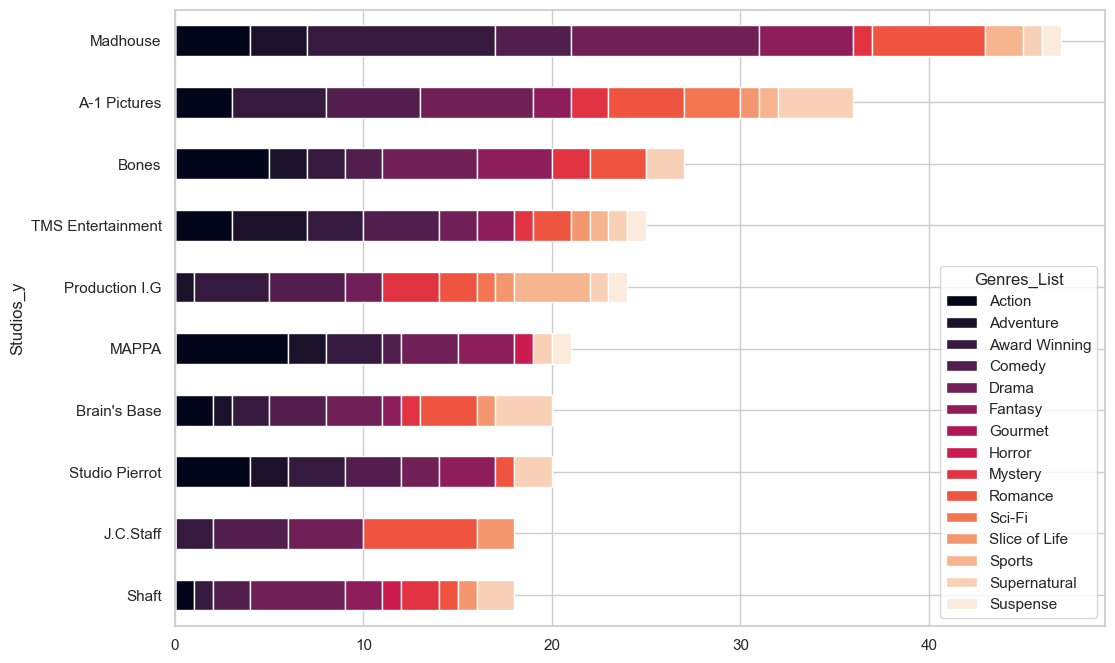

In [31]:
#[Manga & Animation studio Dataframe]
#Top studio and break down of the genres 
top_studios_list = studio_genre_ct.sum(axis=1).nlargest(10).index

#Top to bottom 
plot_data = studio_genre_ct.loc[top_studios_list][::-1]

plot_data.plot(kind='barh', stacked=True, figsize=(12, 8), colormap='rocket')

In [360]:
#[Manga Dataframe]
# Language & Genre affinity map 
lang_genre_df = manga_studio_df[['Languages', 'Genres']].copy().dropna()
lang_genre_df['Genres'] = lang_genre_df['Genres'].str.split(',')
lang_genre_df = lang_genre_df.explode('Genres')
lang_genre_df['Genres'] = lang_genre_df['Genres'].str.strip()

exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love']
lang_genre_df = lang_genre_df[~lang_genre_df['Genres'].isin(exclude_list)]

lang_genre_ct = pd.crosstab(lang_genre_df['Languages'], lang_genre_df['Genres'])

# ratio of the studio genre cross tabl 
lang_genre_pct = lang_genre_ct.div(lang_genre_ct.sum(axis=0), axis=1)

#print(lang_genre_pct.head())

In [359]:
#[Manga Dataframe]
#Affinity assessment between language and genres 
affinity_df = manga_studio_df[['Languages', 'Genres']].copy().dropna()

#Exploding the Genres 
affinity_df['Genres'] = affinity_df['Genres'].str.split(',')
affinity_df = affinity_df.explode('Genres')
affinity_df['Genres'] = affinity_df['Genres'].str.strip()

#Splitting languages 
affinity_df['Languages'] = affinity_df['Languages'].str.split(',')
affinity_df = affinity_df.explode('Languages')
affinity_df['Languages'] = affinity_df['Languages'].str.strip()

#Filtering unnecessary ones 
exclude_genres = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love']
exclude_langs = ['None']

affinity_df = affinity_df[~affinity_df['Genres'].isin(exclude_genres)]
affinity_df = affinity_df[~affinity_df['Languages'].isin(exclude_langs)]

#Crosstab of Language and Genres 
affinity_ct = pd.crosstab(affinity_df['Languages'], affinity_df['Genres'])

#Calculating percentage
affinity_pct = affinity_ct.div(affinity_ct.sum(axis=1), axis=0)
affinity_df.to_csv('language_genre_dataset.csv', index=False)
print("Data saved to 'language_genre_dataset.csv'!")

Data saved to 'language_genre_dataset.csv'!


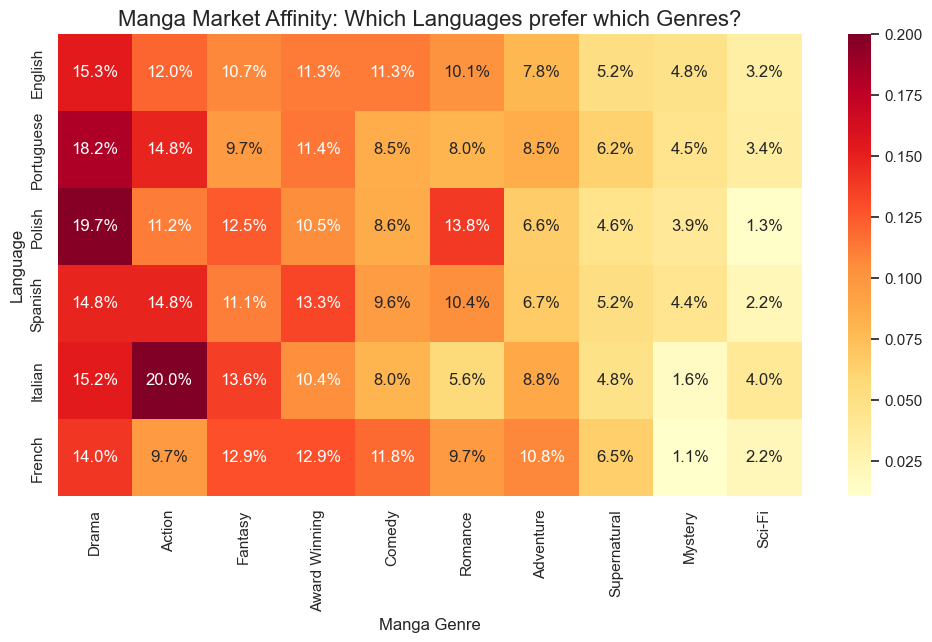

In [281]:
#[Manga Dataframe]
#Top 6 languages including French and checking the affinity mapping 
top_langs = affinity_df['Languages'].value_counts().nlargest(6).index
top_genres = affinity_df['Genres'].value_counts().nlargest(10).index
final_map = affinity_pct.loc[top_langs, top_genres]

plt.figure(figsize=(12, 6))
sns.heatmap(final_map, annot=True, cmap="YlOrRd", fmt=".1%")

plt.title('Manga Market Affinity: Which Languages prefer which Genres?', fontsize=16)
plt.ylabel('Language')
plt.xlabel('Manga Genre')
plt.show()

In [33]:
#[Manga/Merch/Anime combined Dataframe]
#Create a unified Studio Strength DF
manga_merch_combined = merch_anime_df.merge(
    manga_studio_df[['Anime_ID', 'Genres', 'Languages', 'Streaming', 'Award_count', 'Language_count', 'Studios_y', 'Genres', 'Comic Mag']], 
    on='Anime_ID', 
    how='left'
)
manga_merch_combined.head(3)

,Anime_ID,Title,Originated_From,Story_DNA,Popularity_Rank,Score,Reach_Members,Loyalty_Favourites,Main_Genre,Studios,...,Long_Tail_Astudio,Merch_quantity,Genres,Languages,Streaming,Award_count,Language_count,Studios_y,Genres,Comic Mag
0,52991,Sousou no Frieren,0,During their decade-long quest to defeat the D...,113,9.28,1319180,83317,0,0,...,0,0,"Adventure, Award Winning, Drama, Fantasy","English, Polish",viz,2.0,2.0,Madhouse,"Adventure, Award Winning, Drama, Fantasy",Shounen Sunday
1,5114,Fullmetal Alchemist: Brotherhood,0,After a horrific alchemy experiment goes wrong...,3,9.10,3628507,239718,2,2,...,0,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9253,Steins;Gate,1,Eccentric scientist Rintarou Okabe has a never...,14,9.07,2773782,200310,3,3,...,0,2,"Sci-Fi, Suspense",None,None,0.0,0.0,White Fox,"Sci-Fi, Suspense",N/A


In [34]:
#[Manga/Merch/Anime combined Dataframe]
# Prioritising the descriptive studio string over the ID
#SORT STUDIO BY GLOBAL POWER 
manga_merch_combined['Studios_Final'] = manga_merch_combined['Studios_y'].fillna('Unknown')

#Filling NaN in metrics to ensure global_power calculation works
manga_merch_combined['Merch_quantity'] = manga_merch_combined['Merch_quantity'].fillna(0)
manga_merch_combined['Language_count'] = manga_merch_combined['Language_count'].fillna(1) # Assume at least 1 language
manga_merch_combined['is_netflix'] = manga_merch_combined['Streaming'].str.contains('netflix', case=False, na=False).astype(int)

#Defining the Global Power Score (Normalized)
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

manga_merch_combined['loyalty_ratio'] = manga_merch_combined['Loyalty_Favourites'] / manga_merch_combined['Reach_Members']
manga_merch_combined['global_power'] = (
    normalize(manga_merch_combined['loyalty_ratio']) + 
    normalize(manga_merch_combined['Merch_quantity']) + 
    normalize(manga_merch_combined['Language_count']) + 
    manga_merch_combined['is_netflix']
)
manga_merch_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247 entries, 0 to 246
Data columns (total 29 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            247 non-null    int64  
 1   Title               247 non-null    object 
 2   Originated_From     247 non-null    int64  
 3   Story_DNA           247 non-null    object 
 4   Popularity_Rank     247 non-null    int64  
 5   Score               247 non-null    float64
 6   Reach_Members       247 non-null    int64  
 7   Loyalty_Favourites  247 non-null    int64  
 8   Main_Genre          247 non-null    int64  
 9   Studios             247 non-null    int64  
 10  Producers           247 non-null    object 
 11  Licensors           247 non-null    object 
 12  Episodes            246 non-null    float64
 13  Airing_Year         213 non-null    float64
 14  Rating              0 non-null      float64
 15  Long_Tail_Astudio   247 non-null    int64  
 16  Merch_qu

In [95]:
#[Manga/Merch/Anime combined Dataframe]
#Genres had duplicates, combining them 
manga_merch_combined = manga_merch_combined.loc[:, ~manga_merch_combined.columns.duplicated()]

#Creating the weighted dataframe 
df_weighted = manga_merch_combined.copy()
df_weighted['Genres'] = df_weighted['Genres'].fillna('').astype(str)

#Exploding 
df_weighted['Genres_List'] = df_weighted['Genres'].str.split(', ')
df_exploded = df_weighted.explode('Genres_List')

#Getting rid of white spaces 
df_exploded['Genres_List'] = df_exploded['Genres_List'].str.strip()

#Filtering genres 
exclude_list = ['Ecchi', 'Hentai', 'Boys Love', 'Girls Love', 'None', '']
df_filtered = df_exploded[~df_exploded['Genres_List'].isin(exclude_list)]

#Pivoting by Global Power
studio_power_pivot = df_filtered.pivot_table(
    index='Studios_Final', 
    columns='Genres_List', 
    values='global_power', 
    aggfunc='sum'
).fillna(0)

print("Pivot Table Created Successfully!")
print(studio_power_pivot.head())
studio_power_pivot.to_csv('Studio_Power_Pivot.csv', index=True, header=True)

Pivot Table Created Successfully!
Genres_List              Action  Adventure  Award Winning    Comedy     Drama  \
Studios_Final                                                                   
8bit                   0.000000   0.000000       1.305640  0.000000  0.000000   
A-1 Pictures           0.399762   0.000000       1.036261  0.831111  1.645058   
Artland                0.000000   0.000000       0.485296  0.000000  0.000000   
Bandai Namco Pictures  0.518421   0.000000       0.000000  0.518421  0.000000   
Bones                  1.637365   0.597311       0.949868  1.072214  1.097260   

Genres_List             Fantasy  Horror   Mystery   Romance    Sci-Fi  \
Studios_Final                                                           
8bit                   1.262951     0.0  0.000000  0.000000  0.000000   
A-1 Pictures           0.000000     0.0  1.724748  1.485047  0.691013   
Artland                0.485296     0.0  0.485296  0.000000  0.000000   
Bandai Namco Pictures  0.000000  

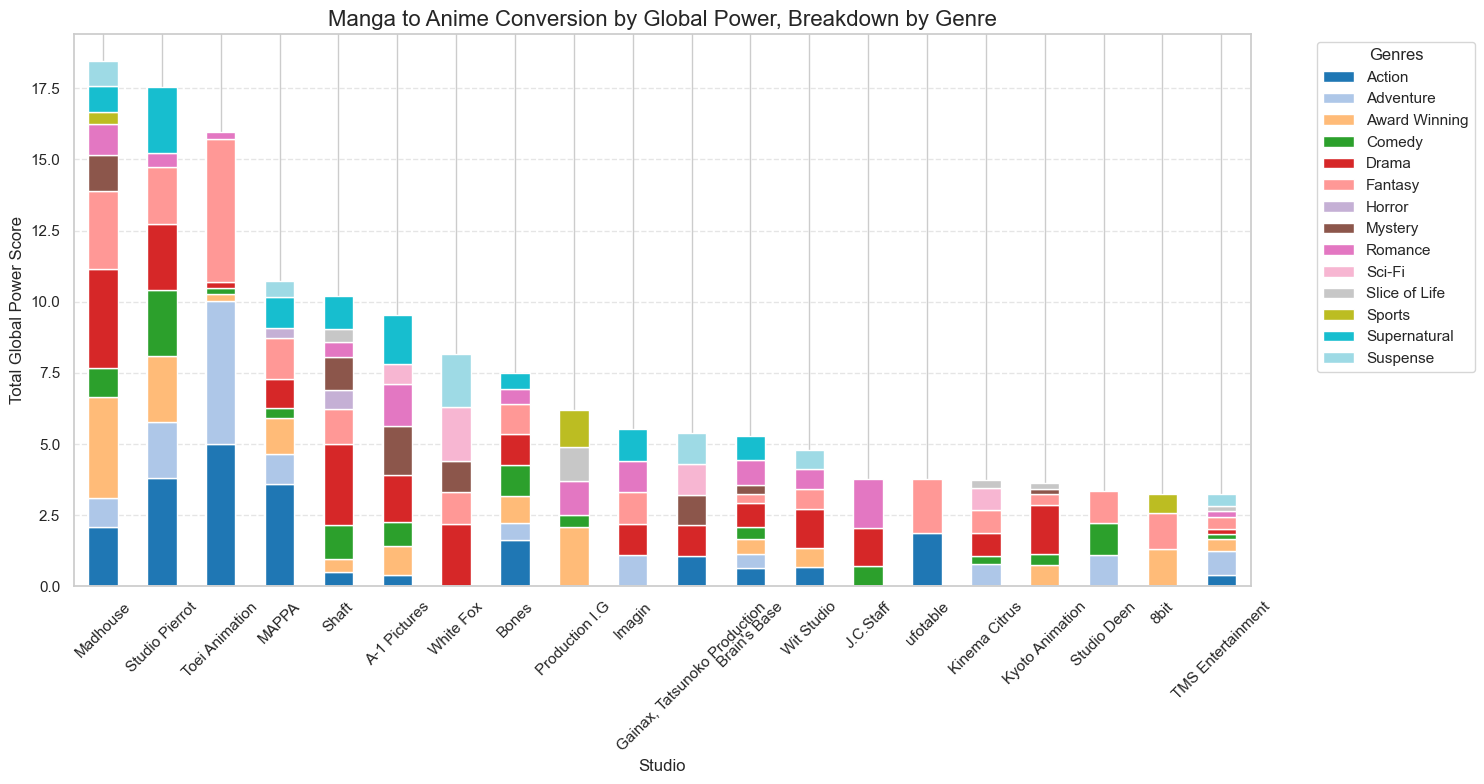

In [36]:
#[Manga/Merch/Anime combined Dataframe]
#Sorting by total power first based on pivot table 
studio_power_pivot['Total'] = studio_power_pivot.sum(axis=1)
studio_plot_df = studio_power_pivot.sort_values('Total', ascending=False).drop(columns='Total')

#Focusing on top 20 
studio_plot_df = studio_plot_df.head(20) 

studio_plot_df.to_csv('manga_anime_studio_strength.csv', index=False)
#Stacked chart 
studio_plot_df.plot(kind='bar', stacked=True, figsize=(15, 8), colormap='tab20')
plt.title('Manga to Anime Conversion by Global Power, Breakdown by Genre', fontsize=16)
plt.xlabel('Studio', fontsize=12)
plt.ylabel('Total Global Power Score', fontsize=12)
plt.legend(title='Genres', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('studio_genre_power_chart.png')
plt.show()

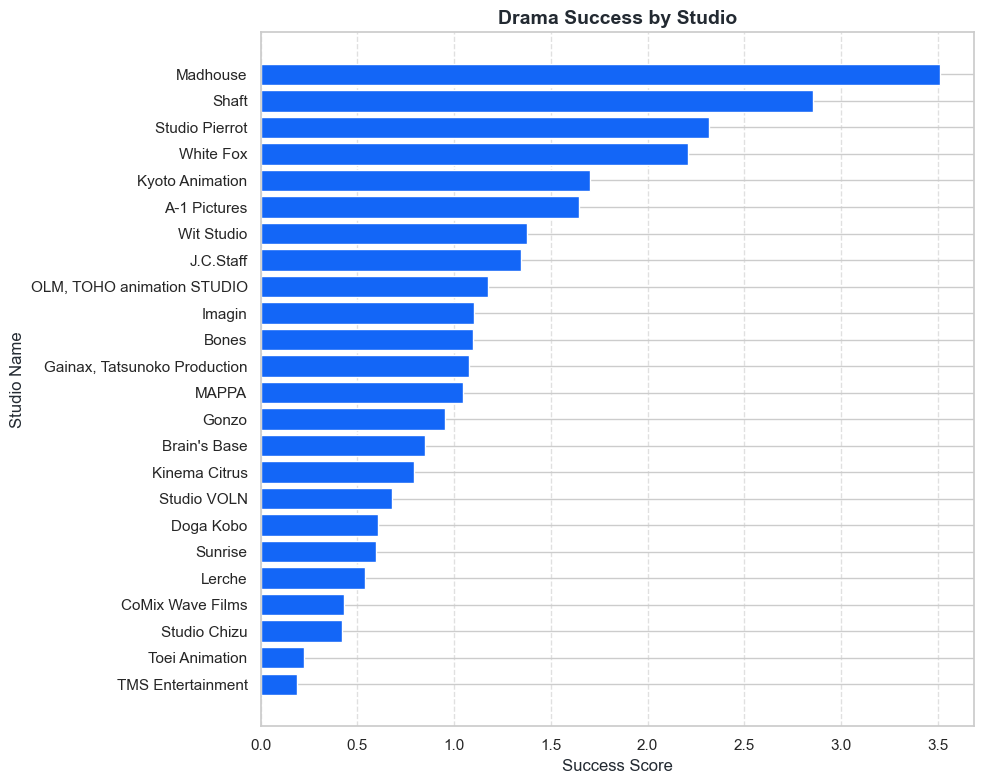

In [118]:
#[Manga/Merch/Anime combined Dataframe]
#Focusing only on Drama 
studio_power_df = pd.read_csv('Studio_Power_Pivot.csv')

plot_data = studio_power_df[studio_power_df['Drama'] > 0].sort_values(by='Drama', ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(y=plot_data['Studios_Final'], 
         width=plot_data['Drama'], 
         color='#1366f7') # slide blue

plt.title('Drama Success by Studio', color='#232a32', fontsize=14, fontweight='bold')
plt.xlabel('Success Score', color='#232a32')
plt.ylabel('Studio Name', color='#232a32')

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [122]:
plot_data.sort_values(by='Drama', ascending=False).head(10)

,Studios_Final,Action,Adventure,Award Winning,Comedy,Drama,Fantasy,Horror,Mystery,Romance,Sci-Fi,Slice of Life,Sports,Supernatural,Suspense
20,Madhouse,2.097951,1.013445,3.540479,1.005140,3.511482,2.732714,0.000000,1.249088,1.092110,0.000000,0.000000,0.43081,0.897489,0.897489
29,Shaft,0.511306,0.000000,0.455362,1.175288,2.857217,1.226568,0.665915,1.175288,0.511306,0.000000,0.455362,0.00000,1.175288,0.000000
33,Studio Pierrot,3.808324,1.980753,2.317466,2.317466,2.317466,1.980753,0.000000,0.000000,0.489895,0.000000,0.000000,0.00000,2.317466,0.000000
39,White Fox,0.000000,0.000000,0.000000,0.000000,2.208848,1.104626,0.000000,1.104222,0.000000,1.872749,0.000000,0.00000,0.000000,1.873153
17,Kyoto Animation,0.000000,0.000000,0.748019,0.408728,1.702731,0.384222,0.000000,0.190892,0.000000,0.000000,0.190892,0.00000,0.000000,0.000000
1,A-1 Pictures,0.399762,0.000000,1.036261,0.831111,1.645058,0.000000,0.000000,1.724748,1.485047,0.691013,0.000000,0.00000,1.724748,0.000000
40,Wit Studio,0.666808,0.000000,0.666808,0.000000,1.374076,0.707267,0.000000,0.000000,0.707267,0.000000,0.000000,0.00000,0.000000,0.666808
14,J.C.Staff,0.000000,0.000000,0.000000,0.724668,1.342839,0.000000,0.000000,0.000000,1.713895,0.000000,0.000000,0.00000,0.000000,0.000000
25,"OLM, TOHO animation STUDIO",0.000000,0.000000,0.000000,0.000000,1.174910,0.000000,0.000000,1.174910,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
13,Imagin,0.000000,1.104800,0.000000,0.000000,1.104800,1.104800,0.000000,0.000000,1.104800,0.000000,0.000000,0.00000,1.104800,0.000000


In [46]:
#[Manga/Merch/Anime combined Dataframe]
#Which studio had more language translated  

# Count how many shows each studio has
studio_counts = manga_merch_combined['Studios_Final'].value_counts()

#Studio with at least 5 series  
prolific_studios = studio_counts[studio_counts >= 5].index

#filtered the studio by above 
filtered_df = manga_merch_combined[manga_merch_combined['Studios_Final'].isin(prolific_studios)]

#Correlation between langugae count and global power 
studio_corrs_clean = (
    filtered_df.groupby('Studios_Final')[['global_power', 'Language_count']]
    .corr()
    .iloc[0::2, -1]
    .reset_index()
    .drop(columns='level_1')
    .rename(columns={'Language_count': 'correlation'})
    .sort_values(by='correlation', ascending=False)
)

print(studio_corrs_clean)


plt.show
lang_studio_df = studio_corrs_clean
lang_studio_df.to_csv('more_lang_more_global_success.csv', index=False)

     Studios_Final  correlation
3  Kyoto Animation     0.919609
2     Brain's Base     0.791659
1            Bones     0.582107
5         Madhouse     0.563365
0     A-1 Pictures     0.301855
4            MAPPA     0.210672
6            Shaft    -0.616698
7          Unknown          NaN


****---------------------------------------[Machine Learning Model Building  with everything we learnt so far]-----------------------------------****

***REDOING THE ML FITTING WITH BIGGER DATASET***

In [23]:
#Attaching LiveOps Column to anime_df 
df_combined = pd.merge(anime_df, liveops_df[['Anime_ID', 'Liveops_count']], 
                       on='Anime_ID', 
                       how='left')

#Attaching Merch Column to anime_df 
df_combined = pd.merge(df_combined, crmerch_df[['Anime_ID', 'Merch_quantity']], 
                       on='Anime_ID', 
                       how='left')

#Filling null with zero 
df_combined['Liveops_count'] = df_combined['Liveops_count'].fillna(0)
df_combined['Merch_quantity'] = df_combined['Merch_quantity'].fillna(0)

print(f"Total Rows: {len(df_combined)}")

Total Rows: 1000


In [28]:
#****************************************************
def calculate_prestige_binary(row):
    # If there was any merch or liveops, its 1 
    if row['Merch_quantity'] > 0 or row['Liveops_count'] > 0:
        return 1
    # High-score/High-loyalty "Potential" hits also count as 1
    if row['Score'] >= 8.0 and row['Loyalty_Favourites'] >= 60000:
        return 1
    return 0

df_combined['prestige_score'] = df_combined.apply(calculate_prestige_binary, axis=1)
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Anime_ID            1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Originated_From     1000 non-null   int64  
 3   Story_DNA           998 non-null    object 
 4   Popularity_Rank     1000 non-null   int64  
 5   Score               1000 non-null   float64
 6   Reach_Members       1000 non-null   int64  
 7   Loyalty_Favourites  1000 non-null   int64  
 8   Main_Genre          1000 non-null   int64  
 9   Studios             1000 non-null   int64  
 10  Producers           1000 non-null   object 
 11  Licensors           1000 non-null   object 
 12  Episodes            990 non-null    float64
 13  Airing_Year         560 non-null    float64
 14  Rating              0 non-null      float64
 15  Long_Tail_Astudio   1000 non-null   int64  
 16  Liveops

In [29]:
#Anime Originals 
originals_df = df_combined[df_combined['Originated_From'] == 4]

#All other Animations 
adaptations_df = df_combined[df_combined['Originated_From'] != 4]

In [65]:
#[Machine Learning Random Forest Classifier]
#1 : Separating Features from Target Column in Surpervised Machine Learning 
features = df_combined.drop(columns=["prestige_score","Title", "merge_key","Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites","is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Anime_Name", "Licensors", "Liveops_count", "loyalty_ratio","Merch_quantity"
], errors='ignore')
target = df_combined["prestige_score"]

In [66]:
#Surpervised Machine Learning Trial 
#Spliting Test & Train 
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [67]:
#[Machine Learning Random Forest Classifier]
#Model fitting
model = RandomForestClassifier(n_estimators=100, random_state=42) 
model.fit(X_train, y_train)

#Evaluating accuracy 
y_pred = model.predict(X_test)
print(f"RF Classifier All Titles dataframe Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")

importances = model.feature_importances_
print(classification_report(y_test, y_pred))

RF Classifier All Titles dataframe Model Accuracy: 93.00%
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       169
           1       0.79      0.74      0.77        31

    accuracy                           0.93       200
   macro avg       0.87      0.85      0.86       200
weighted avg       0.93      0.93      0.93       200



In [87]:
#' Gradient Boosting methods often outperform Random Forest on imbalanced data because they learn sequentially from errors (false negatives) 
#in previous trees, rather than averaging independent trees.'
import xgboost as xgb

#Tuning the imbalance, testing with a Extra Gradient Boost 
ratio = 169 / 31

#XGBoost Modeling with setting parameters 
xgb_model = xgb.XGBClassifier(
    n_estimators=100,      #number of decision tree to be 100
    learning_rate=0.1,    #slower learning speed after HT, GV 0.05 to 0.1  
    max_depth=3,  # tree depth to be changed from 6 to 3 
    subsample=1.0, #for every tree, 200 clues will be looked at 
    scale_pos_weight=ratio, # 5.45 times more as the current ratio in test is 169/31
    use_label_encoder=False,
    eval_metric='logloss',  # index to evaluate the miss 
    random_state=42        # magic number applied to all codes 
)


xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

#report 
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print("--- All Anime Titles Prestige Score Prediction Accuracy ---")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 94.00%
--- All Anime Titles Prestige Score Prediction Accuracy ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       169
           1       0.74      0.94      0.83        31

    accuracy                           0.94       200
   macro avg       0.87      0.94      0.90       200
weighted avg       0.95      0.94      0.94       200



C:\Users\akoki\miniconda3\envs\data_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:02:44] WARNING: C:\miniconda3\conda-bld\xgboost-split_1764761400759\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [125]:
#[XG Boost ML for All Animes]
#Saving the model into Joblib 
import joblib
joblib.dump(xgb_model, 'xgboost_model.pkl')

['xgboost_model.pkl']

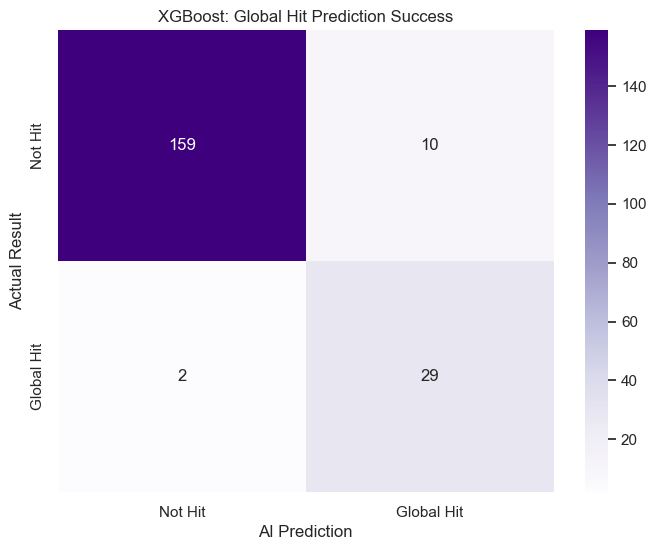

In [88]:
#[XG Boost ML for All Animes]
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Not Hit', 'Global Hit'], 
            yticklabels=['Not Hit', 'Global Hit'])
plt.xlabel('AI Prediction')
plt.ylabel('Actual Result')
plt.title('XGBoost: Global Hit Prediction Success')
plt.show()

In [86]:
#[XG Boost ML for All Animes]
#Hyperparameter Tuning, CV
from sklearn.model_selection import GridSearchCV


# Parameter Grid
# XGBoost specific : learning_rate, max_depth
param_grid = {
    'n_estimators': [100, 200],      # number of trees 
    'learning_rate': [0.01, 0.05, 0.1], # rate bigger is faster
    'max_depth': [3, 5, 7],           # tree depth if deeper, more complex 
    'subsample': [0.8, 1.0]           # per step rate 
}

# Grid Search (Tuning & CV) 
# Defining scoring='f1' as this is imbalanced sample, so its better to assess f1 
grid_search = GridSearchCV(
    xgb_model, 
    param_grid, 
    cv=5, 
    scoring='f1', #strength for imbalance 
    n_jobs=-1     #speeding up 
)

#Learning 
grid_search.fit(X_train, y_train)

#Result 
print(f"Best Parameters: {grid_search.best_params_}")

#Final model 
best_xgb = grid_search.best_estimator_

#Prediction again on test dataset 
final_preds = best_xgb.predict(X_test)

print("=== FINAL TUNED XGBOOST PERFORMANCE ===")
print(f"Accuracy: {accuracy_score(y_test, final_preds):.4f}")
print("-" * 30)
print(classification_report(y_test, final_preds))

Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
=== FINAL TUNED XGBOOST PERFORMANCE ===
Accuracy: 0.9400
------------------------------
              precision    recall  f1-score   support

           0       0.99      0.94      0.96       169
           1       0.74      0.94      0.83        31

    accuracy                           0.94       200
   macro avg       0.87      0.94      0.90       200
weighted avg       0.95      0.94      0.94       200



C:\Users\akoki\miniconda3\envs\data_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:59:35] WARNING: C:\miniconda3\conda-bld\xgboost-split_1764761400759\work\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [90]:
#[XG Boost ML for All Animes]
#Feature Importance
feature_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance for successful All IPs (What drives Globalisation?) ---")
print(feature_results)


--- Feature Importance for successful All IPs (What drives Globalisation?) ---
           Feature  Importance
1  Popularity_Rank    0.639213
2            Score    0.119161
4          Studios    0.113897
3       Main_Genre    0.091285
0  Originated_From    0.036444


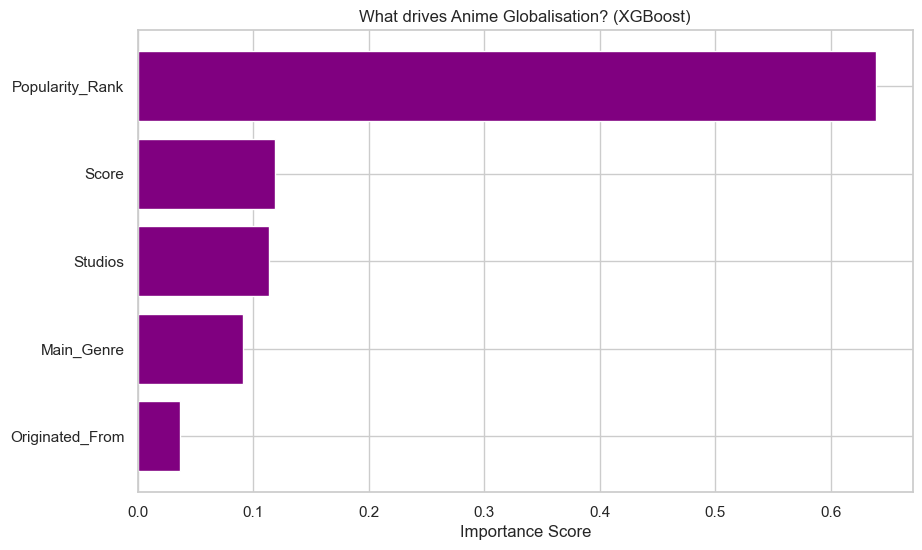

In [94]:
#[XG Boost ML for All Animes]
#Visualising the Feature Importance 
plt.figure(figsize=(10, 6))
plt.barh(feature_results['Feature'][::-1], feature_results['Importance'][::-1], color='purple')
plt.title('What drives Anime Globalisation? (XGBoost)')
plt.xlabel('Importance Score')
plt.show()

In [60]:
#[Machine Learning Random Forest Classifier, Anime Only] 
#1 : Separating Features from Target Column in Surpervised Machine Learning 
features = originals_df.drop(columns=["prestige_score","Title", "merge_key","Episodes", "Airing_Year", "Rating", "Anime_ID", "Loyalty_Favourites","is_hit", "Reach_Members", "Title", "Story_DNA", "Long_Tail_Astudio", "Producers", "Anime_Name", "Licensors", "Liveops_count", "loyalty_ratio","Merch_quantity"
], errors='ignore')
target = originals_df["prestige_score"]

In [61]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size = 0.20, random_state=42)

In [64]:
#[Machine Learning Random Forest Classifier, Anime Only]
#Model fitting
model = RandomForestClassifier(class_weight={0: 1, 1: 3}, random_state=42)
model.fit(X_train, y_train)

# Instead of predict(), use predict_proba()
y_probs = model.predict_proba(X_test)[:, 1]
# Lower the bar to 0.35 to catch more potential hits
y_pred_new = (y_probs >= 0.35).astype(int)

#Evaluating accuracy 
y_pred = model.predict(X_test)
print(f"Anime Only, RF Classifier Model Accuracy: {accuracy_score(y_test, y_pred_new):.2%}")

importances = model.feature_importances_
print(classification_report(y_test, y_pred_new))

Anime Only, RF Classifier Model Accuracy: 87.10%
              precision    recall  f1-score   support

           0       0.88      0.96      0.92        23
           1       0.83      0.62      0.71         8

    accuracy                           0.87        31
   macro avg       0.86      0.79      0.82        31
weighted avg       0.87      0.87      0.86        31



In [57]:
#Feature Importance
feature_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance for Anime Originated IPs (What drives Globalisation?) ---")
print(feature_results)


--- Feature Importance for Anime Originated IPs (What drives Globalisation?) ---
           Feature  Importance
1  Popularity_Rank    0.622599
2            Score    0.170664
4          Studios    0.110863
3       Main_Genre    0.095874
0  Originated_From    0.000000


***ML RF predicting 'Prestige Score' of only Anime Originated Titles***
Model Accuracy: 93.55%
No Prestige Score: 0  -> precision: 0.93 , recall:1.00, f1-score:0.96, support:25

Prestige Score:1  -> precision: 1.00, recall: 0.67,  f1-score:0.80, support:6

    accuracy                              0.94        31
    macro avg         0.96      0.83      0.88        31
 weighted avg         0.94      0.94      0.93        31

-------------------------
 Feature  Importance
1  Popularity_Rank    0.64
2            Score    0.16
4          Studios    0.10
3       Main_Genre    0.08

In [74]:
#manga_df + manga_studio_df  (on manga Id without losing 1000 data thats included in manga_df) 
merged_manga_df = pd.merge(manga_df, 
                           manga_studio_df, 
                           on='Manga_ID', 
                           how='left')
#above + liveops_df (on Anime ID, again without loosing 1000)
manga_final= pd.merge(merged_manga_df, 
                    liveops_df, 
                    on='Anime_ID', 
                    how='left')

manga_final_df = pd.merge(manga_final, 
                    crmerch_df, 
                    on='Anime_ID', 
                    how='left')

# Fill the missing gaps (for items with no merch or no manga info) with 0
manga_final_df = manga_final_df.fillna(0)